In [1]:
import numpy as np
import scipy.integrate as spi
import scipy.optimize as spo
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os
import pickle
from scipy.optimize import brentq, root, minimize_scalar
from scipy.interpolate import interp1d

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

SMALL_SIZE = 18
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [2]:
def read_pdf_theta(directory, fixed_cof, fixed_I, aspect_ratios):

    current_directory = os.getcwd()
    if current_directory.endswith(directory):
        pass
    else:
        os.chdir(directory)
    # initilize data list
    S2_scalar = np.zeros(len(aspect_ratios))
    S4_scalar = np.zeros(len(aspect_ratios))
    biaxiality = np.zeros(len(aspect_ratios))
    theta_d = np.zeros(len(aspect_ratios))
    phi = np.zeros(len(aspect_ratios))
    bin_centers = np.zeros((len(aspect_ratios), 100))
    pdf_data = np.zeros((len(aspect_ratios), 100))
    U_fitted = np.zeros(len(aspect_ratios))
    phi_fluctuations = np.zeros(len(aspect_ratios))
    D_r = np.zeros(len(aspect_ratios))
    shear_rate = np.zeros(len(aspect_ratios))
    rmse = np.zeros(len(aspect_ratios))
    n1_diff = np.zeros(len(aspect_ratios))
    n2_diff = np.zeros(len(aspect_ratios))
    p_yy = np.zeros(len(aspect_ratios))
    p_xy = np.zeros(len(aspect_ratios))
    S2_tensor = np.zeros((len(aspect_ratios), 3, 3))
    S4_tensor = np.zeros((len(aspect_ratios), 3, 3, 3, 3))
    strains = np.zeros((len(aspect_ratios), 3200))
    S2_over_time = np.zeros((len(aspect_ratios), 3200))
    biaxiality_over_time = np.zeros((len(aspect_ratios), 3200))
    angle_over_time = np.zeros((len(aspect_ratios), 3200))
    times = np.zeros((len(aspect_ratios), 510))
    oacf = np.zeros((len(aspect_ratios), 510))
    tau_r = np.zeros(len(aspect_ratios))
    A_infty = np.zeros(len(aspect_ratios))
    omega = np.zeros((len(aspect_ratios), 3))
    screening_jeffrey = np.zeros(len(aspect_ratios))
    error_screening = np.zeros(len(aspect_ratios))
    theta_bins = np.zeros((len(aspect_ratios), 15))
    omega_bins = np.zeros((len(aspect_ratios), 15))
    std_omega_bins = np.zeros((len(aspect_ratios), 15))

    for idx, ap in enumerate(aspect_ratios):
        filename = f'orientation_simple_shear_ap{ap}_cof_{fixed_cof}_I_{fixed_I}.pkl'
        if os.path.exists(filename):
            with open(filename, 'rb') as file:
                file_data = pickle.load(file)
                bin_centers[idx, :] = file_data['bin_centers']
                pdf_data[idx, :] = file_data['f_data']
                S2_scalar[idx] = file_data['S2_scalar']
                S4_scalar[idx] = file_data['S4_scalar']
                biaxiality[idx] = file_data['biaxiality']
                theta_d[idx] = file_data['theta_d']
                U_fitted[idx] = file_data['U_fitted']
                phi[idx] = file_data['phi']
                phi_fluctuations[idx] = file_data['phi_fluct']
                D_r[idx] = file_data['D_r']
                shear_rate[idx] = file_data['shear_rate']
                rmse[idx] = file_data['rmse_fit']
                n1_diff[idx] = file_data['Nx_diff']
                n2_diff[idx] = file_data['Nz_diff']
                p_yy[idx] = file_data['p_yy']
                p_xy[idx] = file_data['p_xy']
                S2_tensor[idx, :, :] = file_data['nematic_tensor']
                S4_tensor[idx, :, :, :, :] = file_data['S4']
                strains[idx, :len(file_data['strains'])
                        ] = file_data['strains']  # zeros in the end
                S2_over_time[idx, :len(file_data['strains'])
                             ] = file_data['S2_over_time']
                biaxiality_over_time[idx, :len(
                    file_data['strains'])] = file_data['biaxility_over_time']
                angle_over_time[idx, :len(
                    file_data['strains'])] = file_data['angle_over_time']
                times[idx, :len(file_data['times'])] = file_data['times']
                oacf[idx, :len(file_data['times'])] = file_data['oacf']
                tau_r[idx] = file_data['tau_r']
                A_infty[idx] = file_data['A_infty']
                omega[idx, :] = file_data['ave_omega'] * shear_rate[idx]**2
                
                screening_jeffrey[idx] = file_data['screening_jeffrey']
                error_screening[idx] = file_data['error_screening']
                theta_bins[idx, :] = file_data['theta_bins']
                omega_bins[idx, :] = file_data['omega_bins']
                std_omega_bins[idx, :] = file_data['std_omega_bins']

    os.chdir('..')  # return to the original directory
    return (bin_centers, pdf_data, S2_scalar, S4_scalar, biaxiality, theta_d, U_fitted,
            phi, phi_fluctuations, D_r, shear_rate, rmse, n1_diff, n2_diff, p_yy, p_xy,
            S2_tensor, S4_tensor, strains, S2_over_time, times, oacf, tau_r, A_infty,
            omega, screening_jeffrey, error_screening, angle_over_time,
            theta_bins, omega_bins, std_omega_bins, biaxiality_over_time)


def P2(x):
    """Calculates the second Legendre polynomial, P₂(x) = (3x² - 1)/2."""
    return 0.5 * (3 * x**2 - 1.0)


def P4(x):
    """Calculates the fourth Legendre polynomial, P₄(x)."""
    return 0.125 * (35 * x**4 - 30 * x**2 + 3)


def fit_equilibrium_ODF(measured_thetas, S, U):
    """
    Maier-Saupe equilibrium distribution per unit solid angle,
    using the second Legendre Polynomial P₂(cosθ).
    Accounts for head-tail symmetry (θ ∈ [0, π/2]).
    Normalization is computed over [0, π/2] and multiplied by 2 to account for symmetry.
    """
    cos_thetas = np.cos(measured_thetas)

    legendre_term = P2(cos_thetas)

    numerator = np.exp(S * U * legendre_term)

    integrand = numerator * np.sin(measured_thetas)
    denominator = 4 * np.pi * np.trapezoid(integrand, x=measured_thetas)

    return numerator / denominator

def fit_equilibrium_ODF_P4(thetas, order_params, interaction_params):
    """
    Equilibrium distribution f(θ) using both P₂ and P₄ terms.
    f(θ) = exp(U₂S₂P₂ + U₄S₄P₄) / Z
    """
    S2, S4 = order_params
    U2, U4 = interaction_params
    cos_thetas = np.cos(thetas)

    potential = U2 * S2 * P2(cos_thetas) + U4 * S4 * P4(cos_thetas)
    numerator = np.exp(potential)

    integrand = numerator * np.sin(thetas)
    denominator = 4 * np.pi * np.trapezoid(integrand, x=thetas)

    return numerator / denominator


def pi_formatter(x, pos):
    frac = x / np.pi
    if np.isclose(frac, 0):
        return "0"
    elif np.isclose(frac, 0.25):
        return r"$\pi/4$"
    elif np.isclose(frac, 1):
        return r"$\pi$"
    elif np.isclose(frac, 0.5):
        return r"$\pi/2$"
    else:
        return fr"${frac:.2f}\pi$"


def second_coeff_excluded_volume(x):
    first_factor = 15 / 32 / x**4
    second_factor = x**2 - 3 + (x**2+3) * (1 - x**2) * np.arctanh(x) / x
    third_factor = 3 - 2 * x**2 + \
        (4 * x**2 - 3)*np.arcsin(x) / (x * np.sqrt(1 - x**2))
    return first_factor * second_factor * third_factor

def parsons_volume_approx_p2(alpha):
    chi = (alpha**2 - 1) / (alpha**2 + 1)
    first_term = 8 / 3 * chi**2
    second_term = 1/np.sqrt(1-chi**2)
    third_term = 1+3*chi**2/14
    return first_term * second_term * third_term

def parsons_volume_approx_p4(alpha):
    """
    Calculates the magnitude of the P4 coefficient 
    from the excluded volume expansion (Eq. 19).
    """
    chi = (alpha**2 - 1) / (alpha**2 + 1)
    global_factor = 8.0 / np.sqrt(1.0 - chi**2)
    p4_factor = (1.0 / 35.0) * chi**4
    return global_factor * p4_factor

def excluded_volume_rod(alpha):
    second_coeff_A_complete = -5 / 32 * np.pi * (8*alpha / np.pi + 2/alpha)
    # second_coeff_A_complete = 16 * alpha / (3*np.pi)
    second_coeff_B_complete = 5/4
    second_coeff_C_complete = 0.385*8/np.pi

    return (second_coeff_A_complete + second_coeff_B_complete + second_coeff_C_complete)

def compute_correction_density(phi):
    """
    Computes the Parsons-Lee correction factor for a given volume fraction phi
    """
    return phi*(1-3/4*phi) / (1-phi)**2

### P_2 only approximation

In [3]:
def find_U_from_S2(target_S2, u_min=0.01, u_max=150.0, tol=1e-7):
    """
    Finds the interaction strength U that self-consistently produces a
    target nematic order parameter S2.
    
    Uses a root-finding algorithm on the function g(U) = solve_self_consistent_S2(U) - target_S2.
    
    Args:
        target_S2 (float): The desired nematic order parameter (e.g., from simulation).
        u_min (float): The lower bound of the search interval for U.
        u_max (float): The upper bound of the search interval for U.
        tol (float): The tolerance for the root-finding.

    Returns:
        float: The self-consistent interaction strength U.
    """
    # Handle the trivial isotropic case where U is effectively zero.
    if target_S2 <= 0.01:
        return 0.0
        
    # Define the objective function whose root we want to find.
    # The root occurs when the S2 produced by a given U equals our target S2.
    def objective_func(U):
        return solve_self_consistent_S2(U) - target_S2
    
    try:
        # Use Brent's method, a robust and fast bracketing root-finder.
        U_solution = brentq(objective_func, u_min, u_max, xtol=tol)
        return U_solution
    except ValueError:
        # This error occurs if the objective function does not have opposite signs
        # at the ends of the interval, meaning there is no root to be found.
        # This can happen if the target_S2 is too high to be physically reachable.
        print(f"Warning: Could not find a self-consistent U for target S2 = {target_S2:.3f}. "
              "The target may be outside the reachable range.")
        return np.nan


def calculate_S2_from_distribution(thetas, U, S2_guess):
    """
    For a given interaction strength U and a guessed order parameter S2_guess,
    this function calculates the resulting order parameter by averaging P₂(cosθ)
    over the corresponding Maier-Saupe distribution.
    """
    cos_thetas = np.cos(thetas)
    
    # Calculate the un-normalized probability
    numerator = np.exp(U * S2_guess * P2(cos_thetas))
    
    # Integrand for the partition function Z (normalization constant)
    integrand_Z = numerator * np.sin(thetas)
    Z_integral = np.trapezoid(integrand_Z, x=thetas)
    
    # Integrand for the average of P2
    integrand_P2 = P2(cos_thetas) * numerator * np.sin(thetas)
    P2_integral = np.trapezoid(integrand_P2, x=thetas)
    
    # Avoid division by zero if the integral is null
    if Z_integral == 0:
        return 0.0
        
    # The new S2 is the correctly weighted average of P2 over the distribution
    S2_new = P2_integral / Z_integral
    return S2_new

def solve_self_consistent_S2(U, initial_guess=0.8, tol=1e-7, max_iter=500):
    """
    Iteratively solves for the self-consistent nematic order parameter S2
    for a given interaction strength U.
    """
    S2 = initial_guess
    # Use a high-resolution grid for accurate numerical integration
    thetas = np.linspace(0, np.pi / 2, 500)
    
    for _ in range(max_iter):
        S2_new = calculate_S2_from_distribution(thetas, U, S2)
        if np.abs(S2 - S2_new) < tol:
            return S2_new  # Converged
        S2 = S2_new
        
    # If max_iter is reached without convergence, it may be the isotropic state
    if S2 < 0.05: # A reasonable threshold for the isotropic phase
        return 0.0
        
    # print(f"Warning: Self-consistency for U={U:.2f} did not converge. Returning last value: {S2:.3f}")
    return S2

def compute_polar_pdf(theta_array, n_bins=100):
    """
    Compute the normalized PDF of polar angles theta_array over [0, pi],
    accounting for spherical geometry (sin(theta) weighting).
    """
    # Bin edges and centers
    bins = np.linspace(0, np.pi/2, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    delta_theta = bins[1] - bins[0]

    # Histogram of theta values
    counts, edges = np.histogram(theta_array, bins=bins)

    # Weight for spherical coordinates (sin(theta))
    sin_theta = np.sin(centers)

    # Normalize to get PDF f(theta), such that:
    # 2π ∫ f(θ) sin(θ) dθ = 1
    pdf = counts / (4 * np.pi * sin_theta * delta_theta * len(theta_array))

    return pdf, edges

def compute_rmse_error(measured_pdf, Us, S_2, bin_centers, d_theta):
    """
    Compute the Root Mean Square Error (RMSE) between the measured PDF and model PDF.
    """

    model = lambda thetas, U: fit_equilibrium_ODF(thetas, S_2, Us) 

    wsse = np.sum((measured_pdf - model(bin_centers, Us))**2)
              #* np.sin(bin_centers) * d_theta)
    rmse_sphere = np.sqrt(wsse / 2)

    return rmse_sphere

def KL_divergence(P, Q, bin_centers):    
    """
    Computes the Kullback-Leibler divergence D_KL(P || Q) for PDFs.
    P and Q are probability *densities* (PDFs).
    delta_theta is the spacing of the bins.
    """
    P_safe = np.clip(P, 1e-10, None)
    Q_safe = np.clip(Q, 1e-10, None)

    # Use np.log2() to get JSD bounded by 0 and 1
    return np.trapezoid(P_safe * np.log2(P_safe / Q_safe), x=bin_centers)

def compute_JS_divergence(measured_pdf, theoretical_pdf, bin_centers):
    """
    Computes the Jensen-Shannon divergence between two probability distributions.
    Assumes all bin centers are equally spaced.
    """
    measured_1d_pdf = measured_pdf * 4 * np.pi * np.sin(bin_centers)
    theoretical_1d_pdf = theoretical_pdf * 4 * np.pi * np.sin(bin_centers)

    measured_1d_pdf /= np.trapezoid(measured_1d_pdf, x=bin_centers)
    theoretical_1d_pdf /= np.trapezoid(theoretical_1d_pdf, x=bin_centers)
    
    mean_pdf = 0.5 * (measured_1d_pdf + theoretical_1d_pdf)

    D_KL_measured = KL_divergence(measured_1d_pdf, mean_pdf, bin_centers)
    D_KL_theoretical = KL_divergence(theoretical_1d_pdf, mean_pdf, bin_centers)

    # 6. Jensen-Shannon divergence (now bounded 0 to 1)
    D_JS = 0.5 * (D_KL_measured + D_KL_theoretical)
    return D_JS


### P_2 and P_4 approximation

In [4]:
def calculate_S2_S4_from_distribution_p4(thetas, interaction_params, order_params_guess):
    """
    For a given set of interaction strengths (U₂, U₄) and a guessed
    set of order parameters (S₂_guess, S₄_guess), this function
    calculates the resulting order parameters by averaging P₂(cosθ)
    and P₄(cosθ) over the corresponding equilibrium distribution.
    
    *** This version is robust to numerical overflow. ***
    """
    U2, U4 = interaction_params
    S2_guess, S4_guess = order_params_guess
    cos_thetas = np.cos(thetas)
    
    # Calculate the potential
    potential = U2 * S2_guess * P2(cos_thetas) + U4 * S4_guess * P4(cos_thetas)
    
    V_max = np.max(potential)
    
    # Subtract V_max before exponentiating to prevent overflow
    numerator = np.exp(potential - V_max)
 
    # Integrand for the partition function Z 
    integrand_Z = numerator * np.sin(thetas)
    Z_integral = np.trapezoid(integrand_Z, x=thetas)
    
    # Integrand for the average of P₂
    integrand_P2 = P2(cos_thetas) * numerator * np.sin(thetas)
    P2_integral = np.trapezoid(integrand_P2, x=thetas)

    # Integrand for the average of P₄
    integrand_P4 = P4(cos_thetas) * numerator * np.sin(thetas)
    P4_integral = np.trapezoid(integrand_P4, x=thetas)
    
    # Avoid division by zero if the integral is null
    if Z_integral == 0:
        return 0.0, 0.0
        
    S2_new = P2_integral / Z_integral
    S4_new = P4_integral / Z_integral
    
    return S2_new, S4_new

def solve_self_consistent_S2_S4_p4(interaction_params,
                                   initial_guesses=(0.8, 0.4),
                                   tol=1e-7,
                                   max_iter=500):
    """
    Iteratively solves for the self-consistent nematic order parameters S₂ and S₄
    for a given set of interaction strengths (U₂, U₄).
    """
    S2, S4 = initial_guesses
    U2 , U4 = interaction_params
    # Use a high-resolution grid for accurate numerical integration
    thetas = np.linspace(0, np.pi / 2, 500)
    
    for _ in range(max_iter):
        S2_new, S4_new = calculate_S2_S4_from_distribution_p4(thetas,
                                                              interaction_params,
                                                              (S2, S4))
        
        # Check for convergence in *both* parameters
        if (np.abs(S2 - S2_new) < tol) and (np.abs(S4 - S4_new) < tol):
            return S2_new, S4_new  # Converged
            
        S2, S4 = S2_new, S4_new
        
    # If max_iter is reached, check if it's the isotropic state
    if (S2 < 0.05) and (np.abs(S4) < 0.05):
        print("Warning: Self-consistency reached isotropic state.")
        return 0.0, 0.0
        
    print(f"Warning: Self-consistency for U₂={U2:.2f}, U₄={U4:.2f} did not converge. "
          f"Returning last values: S₂={S2:.3f}, S₄={S4:.3f}")
    return S2_new, S4_new

def find_K_from_S2_S4_p4(target_order_params, 
                         theoretical_U_params, 
                         tol=1e-7):
    """
    Finds the single scaling factor K that best reproduces the target
    (S2, S4) pair, given the *theoretical* interaction strengths.
    
    The potential is V = K * (U_theo_2*S2*P2 + U_theo_4*S4*P4).
    
    Args:
        target_order_params (tuple): (target_S2, target_S4)
        theoretical_U_params (tuple): (U_theo_2, U_theo_4) from PL theory
        
    Returns:
        float: The best-fit scaling factor K.
    """
    target_S2, target_S4 = target_order_params
    U_theo_2, U_theo_4 = theoretical_U_params

    # Handle the trivial isotropic case
    if (target_S2 <= 0.01):
        return 0.0

    # Minimize the sum of squared errors in *both* S2 and S4
    def objective_func(K):
        
        # Scale the theoretical U values by K
        interaction_params = (K * U_theo_2, K * U_theo_4)
        
        # Use targets as the initial guess for the inner loop
        initial_S_guesses = (target_S2, target_S4)
        
        S2_calc, S4_calc = solve_self_consistent_S2_S4_p4(interaction_params,
                                                          initial_S_guesses,
                                                          tol=tol)
        
        # Calculate the total squared error
        error = (S2_calc - target_S2)**2 + (S4_calc - target_S4)**2
        return error

    try:
        # Use a 1D bounded minimizer. We search for K around 1.0
        sol = minimize_scalar(objective_func, bounds=(0.0, 7.0), 
                              method='bounded', tol=tol)
        
        if sol.success:
            return sol.x  # Returns the best-fit K
        else:
            print(f"Warning: Minimization for K failed. Message: {sol.fun}")
            return np.nan
            
    except Exception as e:
        print(f"Error during minimization for K: {e}")
        return np.nan

def find_U_from_S2_S4_p4(target_order_params,
                         initial_U_guesses=(7.0, 0.0),
                         tol=1e-7):
    """
    Finds the interaction strengths (U₂, U₄) that self-consistently
    produce a target set of order parameters (target_S₂, target_S₄).
    
    Uses a 2D root-finding algorithm.
    
    Args:
        target_order_params (tuple): (target_S₂, target_S₄).
        initial_U_guesses (tuple): An initial guess for (U₂, U₄).
        tol (float): The tolerance for the root-finding.

    Returns:
        numpy.ndarray: The self-consistent interaction strengths [U₂, U₄].
    """
    target_S2, target_S4 = target_order_params
    
    # Handle the trivial isotropic case
    if (target_S2 <= 0.01) and (np.abs(target_S4) <= 0.01):
        return np.array([0.0, 0.0])

    # Define the 2D objective function whose root we want to find.
    # The input `U_vec` is a numpy array [U₂, U₄].
    # The output is an error vector [error_S₂, error_S₄].
    def objective_func(U_vec):
        U2, U4 = U_vec
        interaction_params = (U2, U4)
        
        # Use the targets as the initial guess for the *inner* self-consistency
        # This speeds up the root-finding significantly.
        initial_S_guesses = (target_S2, target_S4)
        
        S2_calc, S4_calc = solve_self_consistent_S2_S4_p4(interaction_params,
                                                          initial_S_guesses,
                                                          tol=tol)
        
        error_S2 = S2_calc - target_S2
        error_S4 = S4_calc - target_S4
        
        return [error_S2, error_S4]

    try:
        # Use a robust 2D root-finder
        # 'lm' (Levenberg-Marquardt) is often a good choice.
        sol = root(objective_func, initial_U_guesses, method='lm', tol=tol)
        
        if sol.success:
            return sol.x  # Returns the array [U₂, U₄]
        else:
            print(f"Warning: Root-finding for U's failed. Message: {sol.message}")
            return np.array([np.nan, np.nan])
            
    except Exception as e:
        print(f"Error during root-finding for U's: {e}")
        return np.array([np.nan, np.nan])
    
def compute_rmse_error_p4(pdf_data, interaction_params, order_params, 
                          bin_centers, bin_width, thetas_high_res):
    """
    Computes the RMSE error between the measured PDF and the
    self-consistent P2+P4 Orientational Distribution Function (ODF).
    """
    S2, S4 = order_params
    U2, U4 = interaction_params

    # 1. Get the high-resolution theoretical ODF
    fitted_odf = fit_equilibrium_ODF_P4(thetas_high_res, (S2, S4), (U2, U4))
    
    # 2. Create an interpolator for the theoretical ODF
    odf_interpolator = interp1d(thetas_high_res, fitted_odf, kind='linear', 
                                fill_value="extrapolate")
    
    # 3. Get the theoretical ODF values at the *exact* bin center locations
    odf_at_bin_centers = odf_interpolator(bin_centers)
    
    # 4. Calculate RMSE
    # Ensure PDF is normalized (assuming it's a probability density)
    pdf_norm = pdf_data / (np.sum(pdf_data) * bin_width)
    
    squared_errors = (pdf_norm - odf_at_bin_centers)**2
    rmse = np.sqrt(np.mean(squared_errors))
    
    return rmse

## Vega equation of state

In [5]:
import scipy.special as sp

def compute_geometric_quantities(ap):
    """
    Computes mean radius of curvature, surface area, and volume 
    of an ellipsoid using the general elliptic integral formulas.
    """
    # # Fallback for the perfect sphere to avoid division by zero
    # if np.isclose(ap, 1.0):
    #     V = (4.0 / 3.0) * np.pi
    #     S = 4.0 * np.pi
    #     R = 1.0
    #     return V, S, R

    # Map a to be the shortest axis to keep epsilon > 0
    a = 1.0
    b = 1.0
    c = ap

    epsilon_b = (b/a)**2 - 1.0
    epsilon_c = (c/a)**2 - 1.0

    # SciPy takes m = k^2, so we compute m1 and m2 directly
    m1 = (epsilon_c - epsilon_b) / epsilon_c if epsilon_c != 0 else 0.0
    m2 = (epsilon_b * (1.0 + epsilon_c)) / (epsilon_c * (1.0 + epsilon_b))

    varphi = np.arctan(np.sqrt(epsilon_c))

    # Evaluate incomplete elliptic integrals using m (k^2)
    F_k1 = sp.ellipkinc(varphi, m1)
    E_k1 = sp.ellipeinc(varphi, m1)
    
    F_k2 = sp.ellipkinc(varphi, m2)
    E_k2 = sp.ellipeinc(varphi, m2)

    # 1. Volume
    volume = (4.0 * np.pi / 3.0) * a * b * c

    # 2. Mean Radius of Curvature
    term1_R = np.sqrt((1.0 + epsilon_b) / (1.0 + epsilon_c))
    term2_R = np.sqrt(epsilon_c) * ((1.0 / epsilon_c) * F_k1 + E_k1)
    mean_radius_curvature = (a / 2.0) * (term1_R + term2_R)

    # 3. Surface Area
    term_S = np.sqrt(epsilon_c * (1.0 + epsilon_b)) * ((1.0 / epsilon_c) * F_k2 + E_k2)
    surface_area = 2.0 * np.pi * (a**2) * (1.0 + term_S)

    return volume, surface_area, mean_radius_curvature


def compute_vega_compressibility(ap, phi):
    """
    Computes the Vega compressibility factor (Z) for an isotropic fluid of hard ellipsoids.
    
    Parameters:
    ap (float): Aspect ratio (c/a)
    phi (float): Volume fraction (denoted as 'y' in the equations)
    
    Returns:
    float: Compressibility factor Z
    """
    V, S, R = compute_geometric_quantities(ap)
    
    # 1. Anisotropy parameters
    tau_prime = (4.0 * np.pi * R**2) / S - 1.0
    alpha_prime = (R * S) / (3.0 * V) - 1.0
    
    # 2. Virial Coefficients (Reduced: B_n* = B_n / V^(n-1))
    B2_star = 1.0 + (R * S) / V

    B3_star = 10.0 + 13.094756 * alpha_prime - 2.073909 * tau_prime + \
              4.096689 * (alpha_prime**2) + 2.325342 * (tau_prime**2) - \
              5.791266 * alpha_prime * tau_prime
              
    B4_star = 18.3648 + 27.714434 * alpha_prime - 10.2046 * tau_prime + \
              11.142963 * (alpha_prime**2) + 8.634491 * (tau_prime**2) - \
              28.279451 * alpha_prime * tau_prime - \
              17.190946 * (alpha_prime**2) * tau_prime + \
              24.188979 * alpha_prime * (tau_prime**2) + \
              0.746746 * (alpha_prime**3) - 9.455150 * (tau_prime**3)
              
    B5_star = 28.2245 + 21.288105 * alpha_prime + 4.525788 * tau_prime + \
              36.032793 * (alpha_prime**2) + 59.0098 * (tau_prime**2) - \
              118.407497 * alpha_prime * tau_prime + \
              24.164622 * (alpha_prime**2) * tau_prime + \
              139.766174 * alpha_prime * (tau_prime**2) - \
              50.490244 * (alpha_prime**3) - 120.995139 * (tau_prime**3) + \
              12.624655 * (alpha_prime**3) * tau_prime
              
    # 3. Carnahan-Starling residue term
    cs_fraction = (1.0 + phi + phi**2 - phi**3) / ((1.0 - phi)**3)
    cs_residue = cs_fraction - 1.0 - 4.0*phi - 10.0*(phi**2) - 18.3648*(phi**3) - 28.2245*(phi**4)
    
    # 4. Final Compressibility Factor
    Z = 1.0 + B2_star*phi + B3_star*(phi**2) + B4_star*(phi**3) + B5_star*(phi**4) + \
        (B2_star / 4.0) * cs_residue
        
    return Z

def compute_vega_correction_density(ap, phi):
    """
    Computes the Generalized Parsons-Lee density correction factor 
    by analytically integrating the Vega equation of state.
    
    Parameters:
    ap (float): Aspect ratio (c/a)
    phi (float): Volume fraction
    
    Returns:
    float: Density correction factor F_Vega(phi)
    """
    # 1. Fetch geometric quantities from your existing function
    V, S, R = compute_geometric_quantities(ap)

    # 2. Anisotropy parameters
    tau_prime = (4.0 * np.pi * R**2) / S - 1.0
    alpha_prime = (R * S) / (3.0 * V) - 1.0
    
    # 3. Reduced Virial Coefficients (B_n*)
    B2_star = 1.0 + (R * S) / V
    
    B3_star = 10.0 + 13.094756 * alpha_prime - 2.073909 * tau_prime + \
              4.096689 * (alpha_prime**2) + 2.325342 * (tau_prime**2) - \
              5.791266 * alpha_prime * tau_prime
              
    B4_star = 18.3648 + 27.714434 * alpha_prime - 10.2046 * tau_prime + \
              11.142963 * (alpha_prime**2) + 8.634491 * (tau_prime**2) - \
              28.279451 * alpha_prime * tau_prime - \
              17.190946 * (alpha_prime**2) * tau_prime + \
              24.188979 * alpha_prime * (tau_prime**2) + \
              0.746746 * (alpha_prime**3) - 9.455150 * (tau_prime**3)
              
    B5_star = 28.2245 + 21.288105 * alpha_prime + 4.525788 * tau_prime + \
              36.032793 * (alpha_prime**2) + 59.0098 * (tau_prime**2) - \
              118.407497 * alpha_prime * tau_prime + \
              24.164622 * (alpha_prime**2) * tau_prime + \
              139.766174 * alpha_prime * (tau_prime**2) - \
              50.490244 * (alpha_prime**3) - 120.995139 * (tau_prime**3) + \
              12.624655 * (alpha_prime**3) * tau_prime

    # 4. Analytical integration of the Carnahan-Starling excess free energy
    a_ex_cs = (phi * (4.0 - 3.0 * phi)) / ((1.0 - phi)**2)
    
    # 5. Integral of the CS polynomial residue
    # (Subtracting the contributions of the first 5 virial coefficients of hard spheres)
    cs_residue_integral = a_ex_cs - 4.0*phi - 5.0*(phi**2) - 6.1216*(phi**3) - 7.056125*(phi**4)
    
    # 6. Total Vega excess free energy
    a_ex_vega = B2_star*phi + (B3_star/2.0)*(phi**2) + (B4_star/3.0)*(phi**3) + \
                (B5_star/4.0)*(phi**4) + (B2_star/4.0)*cs_residue_integral
                
    # 7. Generalized correction factor (scaled by the anisotropic B2_star)
    generalized_correction = a_ex_vega / B2_star
    
    return generalized_correction

In [6]:
ap = 1.5 

volume, surface_area, mean_radius_curvature = compute_geometric_quantities(ap)

print(f"Aspect Ratio (ap): {ap}")
print(f"Volume (V): {volume:.4f}")
print(f"Surface Area (S): {surface_area:.4f}")
print(f"Mean Radius of Curvature (R): {mean_radius_curvature:.4f}")


Aspect Ratio (ap): 1.5
Volume (V): 6.2832
Surface Area (S): 16.9182
Mean Radius of Curvature (R): 1.1804


<function matplotlib.pyplot.show(close=None, block=None)>

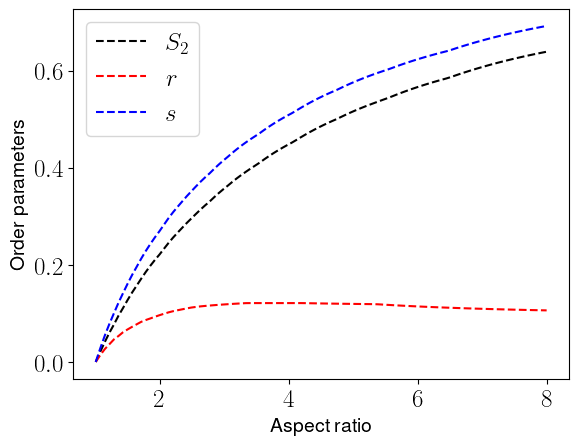

In [7]:
def intepolator(x_data, y_data):
    """
    Generates a 1D linear interpolator from given x and y data.
    """
    interpolator = interp1d(x_data, y_data, kind='linear', fill_value="extrapolate")
    return interpolator

# load data fro biaxiality and s from talbot
biax_no_noise = np.loadtxt('r_talbot.csv', delimiter=',', skiprows=0)
s_no_noise = np.loadtxt('s_talbot.csv', delimiter=',', skiprows=0)
alpha_lin = np.linspace(1, 8, 100)
beta_lin = (alpha_lin**2 - 1) / (alpha_lin**2 + 1)
biaxiality_talbot = intepolator(biax_no_noise[:, 0], biax_no_noise[:, 1])(beta_lin)
s_talbot = intepolator(s_no_noise[:, 0], s_no_noise[:, 1])(beta_lin)
S2_talbot = s_talbot - biaxiality_talbot / 2 # conversion to S2

plt.plot(alpha_lin, S2_talbot, 'k--', label='$S_2$')
plt.plot(alpha_lin, biaxiality_talbot, 'r--', label='$r$')
plt.plot(alpha_lin, s_talbot, 'b--', label='$s$')
plt.legend()
plt.xlabel('Aspect ratio')
plt.ylabel('Order parameters')
plt.show




ap=1.5, U_theo_2=1.481, U_theo_4=0.018, S2_theo=-0.000, S4_theo=-0.000


/tmp/ipykernel_10320/4228105037.py:118: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  sol = minimize_scalar(objective_func, bounds=(0.0, 7.0),


ap=2.5, U_theo_2=8.315, U_theo_4=0.336, S2_theo=0.861, S4_theo=0.614
ap=4.0, U_theo_2=19.522, U_theo_4=1.116, S2_theo=0.952, S4_theo=0.850
ap=6.0, U_theo_2=33.432, U_theo_4=2.152, S2_theo=0.974, S4_theo=0.916
ap=8.0, U_theo_2=51.684, U_theo_4=3.464, S2_theo=0.984, S4_theo=0.946
ap=1.5, U_theo_2=1.347, U_theo_4=0.017, S2_theo=-0.000, S4_theo=-0.000
ap=2.5, U_theo_2=7.251, U_theo_4=0.293, S2_theo=0.829, S4_theo=0.549
ap=4.0, U_theo_2=15.546, U_theo_4=0.889, S2_theo=0.939, S4_theo=0.810
ap=6.0, U_theo_2=23.597, U_theo_4=1.519, S2_theo=0.962, S4_theo=0.879
ap=8.0, U_theo_2=33.015, U_theo_4=2.213, S2_theo=0.974, S4_theo=0.915
ap=1.5, U_theo_2=0.738, U_theo_4=0.009, S2_theo=-0.000, S4_theo=-0.000
ap=2.5, U_theo_2=3.207, U_theo_4=0.130, S2_theo=-0.000, S4_theo=-0.000
ap=4.0, U_theo_2=6.054, U_theo_4=0.346, S2_theo=0.773, S4_theo=0.453
ap=6.0, U_theo_2=8.760, U_theo_4=0.564, S2_theo=0.877, S4_theo=0.651
ap=8.0, U_theo_2=11.004, U_theo_4=0.738, S2_theo=0.909, S4_theo=0.730
Skipping plot for ap=

/tmp/ipykernel_10320/3788836678.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


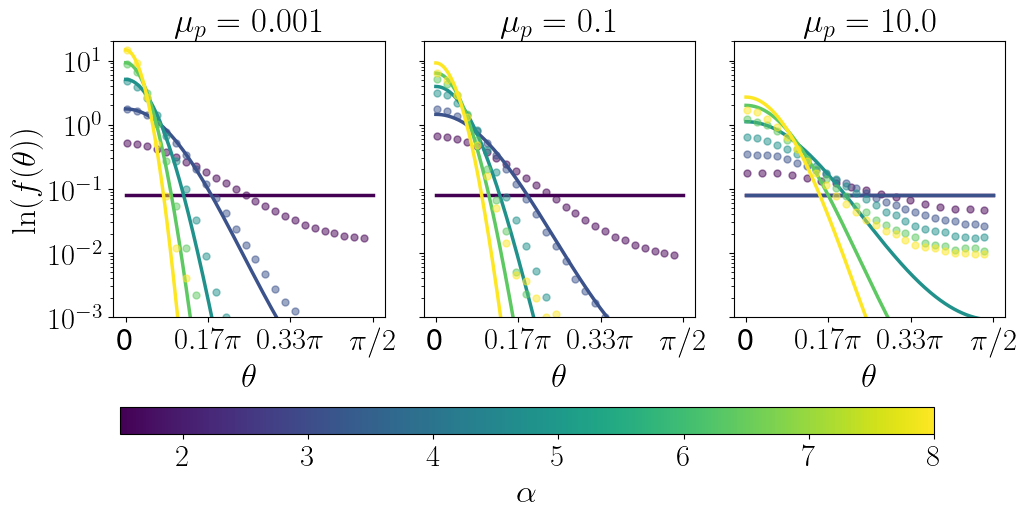

In [8]:
aspect_ratios = np.array([1.5, 2.5, 4.0, 6.0, 8.0])

directory = "output_data_hertz"

thetas = np.linspace(0, np.pi / 2, 200)
cmap = plt.cm.viridis
num_colors = len(aspect_ratios)
length_cmap = cmap.N
delta_color = np.floor(length_cmap / (num_colors-1))
# assign colors to each aspect ratio
colors = [cmap(i*int(delta_color)) for i in range(num_colors)]

I=0.1
cofs = [0.001, 0.1, 10.0]
num_cofs = len(cofs)
fig, axes = plt.subplots(1, num_cofs, figsize=(3.5 * num_cofs, 3.5),  sharey=True)

if num_cofs == 1:
    axes = [axes]

plt.rc('font', size=14)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=14)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=18)   # fontsize of the figure title

# --- Define a high-res theta grid once ---
thetas_high_res = np.linspace(0, np.pi/2, 500)

U1_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))
U2_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))
rmse_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))

for ax, cof in zip(axes, cofs):
    # Read data for the current coefficient of friction
    (bin_centers, pdf_data, S2_scalar, S4_scalar, biaxiality, 
     theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
     rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
     strains, S2_over_time, times, oacf, tau_r, A_infty, 
     omega, screening_jeffrey, error_screening, angle_over_time,
     theta_bins, omega_bins, std_omega_bins, biaxiality_over_time) = read_pdf_theta(directory, cof, I, aspect_ratios)
    
    U1_self_consistent = np.empty_like(S2_scalar)
    U2_self_consistent = np.empty_like(S4_scalar)   
    U_theo_2 = np.empty_like(S2_scalar)
    U_theo_4 = np.empty_like(S4_scalar)
    S2_scalar_theo = np.empty_like(S2_scalar)
    S4_scalar_theo = np.empty_like(S4_scalar)
    
    for i in range(S2_scalar.shape[0]):
        # Get the scalar values for this iteration
        s2_val = S2_scalar[i]
        s4_val = S4_scalar[i]
        phi_val = phi[i]
        ap = aspect_ratios[i]

        # 1. Calculate the *theoretical* U values from Parsons-Lee
        correction_density = 1.08* compute_vega_correction_density(ap, phi_val)  # compute_correction_density(phi_val)
        U_theo_2[i] = correction_density * parsons_volume_approx_p2(ap)
        U_theo_4[i] = correction_density * parsons_volume_approx_p4(ap)

        S2_scalar_theo[i], S4_scalar_theo[i] = solve_self_consistent_S2_S4_p4((U_theo_2[i], U_theo_4[i]),
                                                                       initial_guesses=(s2_val, s4_val))

        print(f"ap={ap}, U_theo_2={U_theo_2[i]:.3f}, U_theo_4={U_theo_4[i]:.3f}, "
              f"S2_theo={S2_scalar_theo[i]:.3f}, S4_theo={S4_scalar_theo[i]:.3f}")

        # 2. Call the new 1D finder function to get the scaling factor K
        K_fitted = find_K_from_S2_S4_p4((s2_val, s4_val), 
                                        (U_theo_2[i], U_theo_4[i]))
        
        if K_fitted < 0.01:
            K_fitted = np.nan

        # 3. Store the final, scaled U values
        U1_self_consistent[i] = K_fitted * U_theo_2[i]
        U2_self_consistent[i] = K_fitted * U_theo_4[i]

    U1_self_consistents[cofs.index(cof), 0, :] = U1_self_consistent
    U2_self_consistents[cofs.index(cof), 0, :] = U2_self_consistent

    for i, ap in enumerate(aspect_ratios):        
        
        # Get the final fitted U and S parameters
        U_params = (U1_self_consistent[i], U2_self_consistent[i])
        S_params = (S2_scalar[i], S4_scalar[i])

        theo_odf = fit_equilibrium_ODF_P4(thetas_high_res, (S2_scalar_theo[i], S4_scalar_theo[i]), 
                                          (U_theo_2[i], U_theo_4[i]))


        # Check for bad fits (NaNs)
        if np.isnan(U_params[0]):
            ax.semilogy(bin_centers[i, ::6], pdf_data[i, ::6], 'o', linestyle='', markersize=5, color=colors[i], alpha=0.5)
            ax.semilogy(thetas_high_res, theo_odf, label=f'$\\alpha={ap}$', linestyle='-', linewidth=2.5, color=colors[i])
            print(f"Skipping plot for ap={ap}, bad K fit.")
            continue
            
        # Get the ODF using the final fitted parameters
        fitted_odf = fit_equilibrium_ODF_P4(thetas_high_res, S_params, U_params)
        
        # Compute RMSE error between measured PDF and fitted ODF
        d_theta = bin_centers[i, 1] - bin_centers[i, 0]
        rmse_error = compute_rmse_error_p4(pdf_data[i, :], U_params, S_params, 
                                           bin_centers[i, :], d_theta, thetas_high_res)
        rmse_self_consistents[cofs.index(cof), 0, i] = rmse_error

        # Plot fitted ODF and PDF data
        # ax.semilogy(thetas_high_res, fitted_odf, label=f'$\\alpha={ap}$', linestyle='--', linewidth=2.5, color=colors[i])
        # ax.semilogy(bin_centers[i, ::4], pdf_data[i, ::4], 'o', linestyle='', markersize=5, color=colors[i], alpha=0.5)
        # ax.semilogy(thetas_high_res, theo_odf, linestyle='-', linewidth=2.5, color=colors[i], alpha=1.0)
        ax.semilogy(bin_centers[i, ::4], pdf_data[i, ::4], 'o', linestyle='', markersize=5, color=colors[i], alpha=0.5)
        ax.semilogy(thetas_high_res, theo_odf, linestyle='-', linewidth=2.5, color=colors[i], alpha=1.0)
        
    # ax.set_ylim(1e-5, 30)
    # ax.set_ylim(1e-5, 30)
    ax.set_xlabel('$\\theta$', fontsize=24)
    ax.set_title(f'$\\mu_p = {cof}$', fontsize=25)
    ax.set_ylim(1e-3, 20)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 6))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(pi_formatter))
# ax.legend(fontsize=20, bbox_to_anchor=(1.05, 1.0), loc='upper left', ncol=1)

# Normalize aspect_ratios (alpha values) to [0, 1] range for colormap
norm = mcolors.Normalize(vmin=min(aspect_ratios), vmax=max(aspect_ratios))
sm = cm.ScalarMappable(cmap='viridis', norm=norm)  # use your same colormap
sm.set_array([])  # Needed only for matplotlib < 3.1

# Add colorbar below the subplots
cbar = plt.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.3,  aspect=30, anchor=(0.5, -2.5))
cbar.set_label(r'$\alpha$', fontsize=24)
cbar.ax.tick_params(labelsize=22)

# Set common Y label
axes[0].set_ylabel('$\\ln(f(\\theta))$', fontsize=24)

# Make all tick labels larger
for ax in axes:
    ax.tick_params(axis='both', labelsize=22)

plt.tight_layout()
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.savefig(f"pdf_comparison_Is_{I}.svg", dpi=300, bbox_inches='tight')
plt.show()

ap=1.5, U_theo_2=1.482, U_theo_4=0.018, S2_theo=-0.000, S4_theo=-0.000
ap=2.5, U_theo_2=8.295, U_theo_4=0.335, S2_theo=0.860, S4_theo=0.613
ap=4.0, U_theo_2=19.523, U_theo_4=1.117, S2_theo=0.952, S4_theo=0.850
ap=6.0, U_theo_2=33.104, U_theo_4=2.130, S2_theo=0.974, S4_theo=0.915
ap=8.0, U_theo_2=52.334, U_theo_4=3.508, S2_theo=0.984, S4_theo=0.947
ap=1.5, U_theo_2=1.347, U_theo_4=0.017, S2_theo=-0.000, S4_theo=-0.000
ap=2.5, U_theo_2=7.251, U_theo_4=0.293, S2_theo=0.829, S4_theo=0.549
ap=4.0, U_theo_2=15.546, U_theo_4=0.889, S2_theo=0.939, S4_theo=0.810
ap=6.0, U_theo_2=23.597, U_theo_4=1.519, S2_theo=0.962, S4_theo=0.879
ap=8.0, U_theo_2=33.015, U_theo_4=2.213, S2_theo=0.974, S4_theo=0.915
ap=1.5, U_theo_2=0.738, U_theo_4=0.009, S2_theo=-0.000, S4_theo=-0.000
ap=2.5, U_theo_2=3.207, U_theo_4=0.130, S2_theo=-0.000, S4_theo=-0.000
ap=4.0, U_theo_2=6.054, U_theo_4=0.346, S2_theo=0.773, S4_theo=0.453
ap=6.0, U_theo_2=8.760, U_theo_4=0.564, S2_theo=0.877, S4_theo=0.651
ap=8.0, U_theo_2=11.

/tmp/ipykernel_10320/3931752201.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


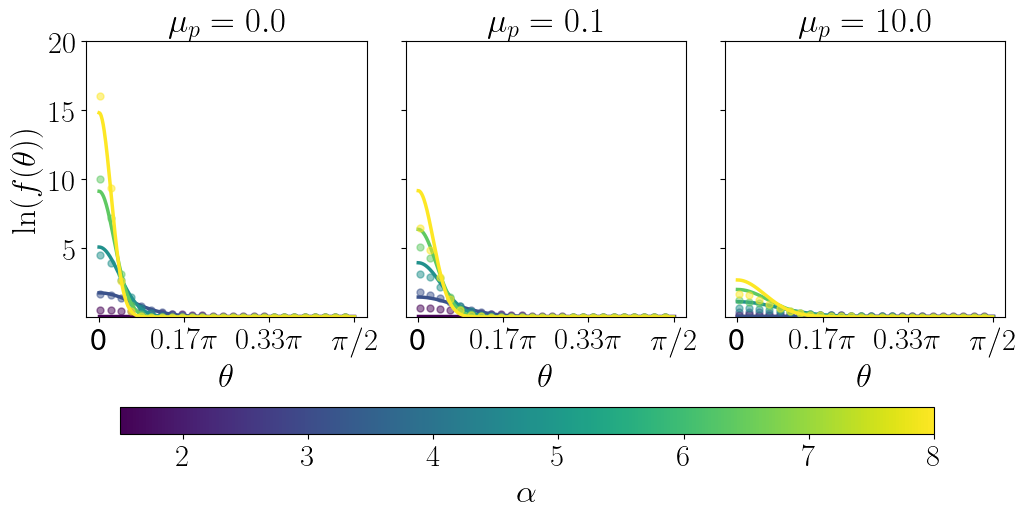

In [9]:
aspect_ratios = np.array([1.5, 2.5, 4.0, 6.0, 8.0])

directory = "output_data_hertz"

thetas = np.linspace(0, np.pi / 2, 200)
cmap = plt.cm.viridis
num_colors = len(aspect_ratios)
length_cmap = cmap.N
delta_color = np.floor(length_cmap / (num_colors-1))
# assign colors to each aspect ratio
colors = [cmap(i*int(delta_color)) for i in range(num_colors)]

I=0.1
cofs = [0.0, 0.1, 10.0]
num_cofs = len(cofs)
fig, axes = plt.subplots(1, num_cofs, figsize=(3.5 * num_cofs, 3.5),  sharey=True)

if num_cofs == 1:
    axes = [axes]

plt.rc('font', size=14)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=14)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
plt.rc('ytick', labelsize=12)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=18)   # fontsize of the figure title

# --- Define a high-res theta grid once ---
thetas_high_res = np.linspace(0, np.pi/2, 500)

U1_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))
U2_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))
rmse_self_consistents = np.zeros((len(cofs), 1, len(aspect_ratios)))

for ax, cof in zip(axes, cofs):
    # Read data for the current coefficient of friction
    (bin_centers, pdf_data, S2_scalar, S4_scalar, biaxiality, 
     theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
     rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
     strains, S2_over_time, times, oacf, tau_r, A_infty, 
     omega, screening_jeffrey, error_screening, angle_over_time,
     theta_bins, omega_bins, std_omega_bins, biaxiality_over_time) = read_pdf_theta(directory, cof, I, aspect_ratios)
    
    U_theo_2 = np.empty_like(S2_scalar)
    U_theo_4 = np.empty_like(S4_scalar)
    S2_scalar_theo = np.empty_like(S2_scalar)
    S4_scalar_theo = np.empty_like(S4_scalar)
    rmse_theoretical = np.zeros(len(aspect_ratios))
    
    for i in range(S2_scalar.shape[0]):
        # Get the scalar values for this iteration
        s2_val = S2_scalar[i]
        s4_val = S4_scalar[i]
        phi_val = phi[i]
        ap = aspect_ratios[i]

        # 1. Calculate the *pure theoretical* U values from Parsons-Lee geometry
        # Removed the arbitrary 1.08 multiplier.
        correction_density = compute_vega_correction_density(ap, phi_val)
        U_theo_2[i] = 1.08* correction_density * parsons_volume_approx_p2(ap)
        U_theo_4[i] = 1.08* correction_density * parsons_volume_approx_p4(ap)

        # 2. Solve for the theoretical S2 and S4 using self-consistency
        S2_scalar_theo[i], S4_scalar_theo[i] = solve_self_consistent_S2_S4_p4(
            (U_theo_2[i], U_theo_4[i]),
            initial_guesses=(s2_val, s4_val) # Using sim values just to seed the root finder
        )

        print(f"ap={ap}, U_theo_2={U_theo_2[i]:.3f}, U_theo_4={U_theo_4[i]:.3f}, "
              f"S2_theo={S2_scalar_theo[i]:.3f}, S4_theo={S4_scalar_theo[i]:.3f}")

        # 3. Generate the strictly predictive theoretical ODF
        theo_odf = fit_equilibrium_ODF_P4(
            thetas_high_res, 
            (S2_scalar_theo[i], S4_scalar_theo[i]), 
            (U_theo_2[i], U_theo_4[i])
        )

        # 4. Compute RMSE between the simulation data and the PURE prediction
        d_theta = bin_centers[i, 1] - bin_centers[i, 0]
        rmse_error = compute_rmse_error_p4(
            pdf_data[i, :], 
            (U_theo_2[i], U_theo_4[i]), 
            (S2_scalar_theo[i], S4_scalar_theo[i]), 
            bin_centers[i, :], d_theta, thetas_high_res
        )
        rmse_theoretical[i] = rmse_error

        # 5. Plotting
        # Scatter plot: Actual simulation data
        ax.plot(bin_centers[i, ::4], pdf_data[i, ::4], 'o', 
                    linestyle='', markersize=5, color=colors[i], alpha=0.5)
        
        # Solid line: Pure Parsons-Lee theoretical prediction
        ax.plot(thetas_high_res, theo_odf, 
                    linestyle='-', linewidth=2.5, color=colors[i], alpha=1.0)
        
    ax.set_xlabel('$\\theta$', fontsize=24)
    ax.set_title(f'$\\mu_p = {cof}$', fontsize=25)
    ax.set_ylim(1e-3, 20)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 6))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(pi_formatter))

# Normalize aspect_ratios (alpha values) to [0, 1] range for colormap
norm = mcolors.Normalize(vmin=min(aspect_ratios), vmax=max(aspect_ratios))
sm = cm.ScalarMappable(cmap='viridis', norm=norm) 
sm.set_array([]) 

# Add colorbar above the subplots
cbar = plt.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.3,  aspect=30, anchor=(0.5, -2.5))
cbar.set_label(r'$\alpha$', fontsize=24)
cbar.ax.tick_params(labelsize=22)

# Set common Y label
axes[0].set_ylabel('$\\ln(f(\\theta))$', fontsize=24)

# Make all tick labels larger
for ax in axes:
    ax.tick_params(axis='both', labelsize=22)

plt.tight_layout()
plt.savefig(f"pdf_comparison_Is_{I}_PREDICTIVE.svg", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# # compare the measured nematic order parameter with the self-consistent solution using U_fitted

# # Create a new figure for the self-consistency check
# fig_sc, axes_sc = plt.subplots(1, num_cofs, figsize=(6 * num_cofs, 6), sharey=True)
# if num_cofs == 1:
#     axes_sc = [axes_sc]

# fig_sc.suptitle('Self-Consistency Check of Maier-Saupe Theory', fontsize=20, y=1.02)

# # Loop through each coefficient of friction
# for ax, cof in zip(axes_sc, cofs):
#     # Read the data for the current coefficient of friction
#     # This call should be identical to the one in your main plotting loop
#     (bin_centers, pdf_data, S2_scalar, S4_scalar, biaxiality, 
#      theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
#      rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
#      strains, S2_over_time, times, oacf, tau_r, A_infty, 
#      omega, screening_jeffrey, error_screening, angle_over_time,
#      theta_bins, omega_bins, std_omega_bins, biaxiality_over_time) = read_pdf_theta(directory, cof, I, aspect_ratios)

#     # For each aspect ratio, use the fitted U to solve for the self-consistent S2
#     S2_self_consistent = [solve_self_consistent_S2(U) for U in U_fitted]

#     # Plot the S2 measured directly from the simulation particle orientations
#     ax.plot(aspect_ratios, S2_scalar, 'o-', color='black', label='Measured $S_2$')
    
#     # Plot the theoretical S2 that is self-consistent with the fitted U
#     ax.plot(aspect_ratios, S2_self_consistent, 's--', color='red', label='Self-Consistent $S_2$')
    
#     ax.set_title(f'$\\mu_p = {cof}$')
#     ax.set_xlabel('$\\alpha$')
#     ax.set_ylim(0, 1.05)
#     ax.grid(True, linestyle='--')
#     ax.legend()

# # Set common labels and finalize the plot
# axes_sc[0].set_ylabel('$S_2$')
# plt.tight_layout()
# plt.savefig(f"self_consistency_check_Is_{I}.png", dpi=300, bbox_inches='tight')
# plt.show()

# # Create a new figure for the inverse self-consistency check
# fig_u, axes_u = plt.subplots(1, num_cofs, figsize=(6 * num_cofs, 6), sharey=True)
# if num_cofs == 1:
#     axes_u = [axes_u]

# fig_u.suptitle('Inverse Self-Consistency Check: Comparing U values', fontsize=20, y=1.02)

# # Loop through each coefficient of friction
# for ax, cof in zip(axes_u, cofs):
#     # Read the data for the current coefficient of friction
#     (bin_centers, pdf_data, S2_scalar, biaxiality, 
#      theta_d, U_fitted, phi, phi_fluctuations, D_r, shear_rate,
#      rmse, n1_diff, n2_diff, p_yy, p_xy, S2_tensor, S4_tensor, 
#      strains, S2_over_time, times, oacf, tau_r, A_infty, 
#      omega, screening_jeffrey, error_screening, angle_over_time,
#      theta_bins, omega_bins, std_omega_bins, biaxiality_over_time) = read_pdf_theta(directory, cof, I, aspect_ratios)

#     # For each aspect ratio, use the measured S2 to find the self-consistent U
#     U1_self_consistent = [find_U_from_S2(s2) for s2 in S2_scalar]

#     # Plot the U obtained by fitting the distribution's shape
#     ax.plot(aspect_ratios, U_fitted, 'o-', color='black', label='Fitted $U$ (from shape)')
    
#     # Plot the theoretical U that is self-consistent with the measured S2
#     ax.plot(aspect_ratios, U1_self_consistent, 's--', color='red', label='Self-Consistent $U$ (from $S_2$)')
    
#     ax.set_title(f'$\\mu_p = {cof}$')
#     ax.set_xlabel('$\\alpha$')
#     ax.grid(True, linestyle='--')
#     ax.legend()

# # Set common labels and finalize the plot
# axes_u[0].set_ylabel('$U$')
# plt.tight_layout()
# plt.savefig(f"inverse_self_consistency_check_Is_{I}.png", dpi=300, bbox_inches='tight')
# plt.show()



In [11]:
aspect_ratios = np.array(
    [1.2, 1.5, 1.8, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 7.0, 8.0])
Is = [0.1]
cofs = np.array([0.0, 0.001, 0.01, 0.1, 0.4, 1.0, 10.0, 100.0])


biaxiality = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
S2_scalar = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
S4_scalar = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
S2_scalar_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
S4_scalar_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
U2_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
U4_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
theta_d = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
U_fitted = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
phis = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
phi_fluctuations = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
D_r = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
shear_rates = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
rmse = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
n1_diff = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
n2_diff = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
p_yy = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
p_xy = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
S2_tensor = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3, 3))
S4_tensor = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3, 3, 3, 3))
# Initialize arrays to store strains, S2_over_time, times, and oacf
strains = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3200))
S2_over_time = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3200))
biaxiality_over_time = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3200))
angle_over_time = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3200))
times = np.zeros((len(cofs), len(Is), len(aspect_ratios), 510))
oacf = np.zeros((len(cofs), len(Is), len(aspect_ratios), 510))
tau_r = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
A_infty = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
# Initialize arrays for omega, screening_jeffrey, error_screening, and angle_over_time
omega = np.zeros((len(cofs), len(Is), len(aspect_ratios), 3))
screening_jeffrey = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
error_screening = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
#
theta_bins = np.zeros((len(cofs), len(Is), len(aspect_ratios), 15))
omega_bins = np.zeros((len(cofs), len(Is), len(aspect_ratios), 15))
std_omega_bins = np.zeros((len(cofs), len(Is), len(aspect_ratios), 15))

rmse_self_consistents = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
JS_divergence = np.zeros((len(cofs), len(Is), len(aspect_ratios)))

loaded = False

try:
    with open(os.path.join(directory, "U_and_rmse_self_consistent.pkl"), 'rb') as f:
        data_loaded = pickle.load(f)
    U1_self_consistents = data_loaded['U1_self_consistents']
    U2_self_consistents = data_loaded['U2_self_consistents']
    rmse_self_consistents = data_loaded['rmse_self_consistents']
    JS_divergence = data_loaded['JS_divergence']

    print("Loaded saved data successfully.")
    loaded = True
except (FileNotFoundError, KeyError):
    print("U_and_rmse_self_consistent.pkl not found or invalid, initializing arrays...")
    U1_self_consistents = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
    U2_self_consistents = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
    rmse_self_consistents = np.zeros(
        (len(cofs), len(Is), len(aspect_ratios)))  # if you need this too

for i_cof, fixed_cof in enumerate(cofs):
    for i_I, fixed_I in enumerate(Is):
        (bin_centers, pdf_data, S2_scalar_temp, S4_scalar_temp, biaxiality_temp, theta_d_temp,
         U_fitted_temp, phi_temp, phi_fluct_temp, D_r_temp, shear_rate_temp,
         rmse_temp, n1_diff_temp, n2_diff_temp, p_yy_temp, p_xy_temp,
         S2_tensor_temp, S4_tensor_temp,
         strains_temp, S2_over_time_temp, times_temp, oacf_temp, tau_r_temp, A_infty_temp,
         omega_temp, screening_jeffrey_temp, error_screening_temp, angle_over_time_temp,
            theta_bins_temp, omega_bins_temp, std_omega_bins_temp, biaxiality_over_time_temp
         ) = read_pdf_theta(directory, fixed_cof, fixed_I, aspect_ratios)

        for i_alpha in range(len(aspect_ratios)):
            biaxiality[i_cof, i_I, i_alpha] = biaxiality_temp[i_alpha]
            S2_scalar[i_cof, i_I, i_alpha] = S2_scalar_temp[i_alpha]
            S4_scalar[i_cof, i_I, i_alpha] = S4_scalar_temp[i_alpha]
            theta_d[i_cof, i_I, i_alpha] = theta_d_temp[i_alpha]
            U_fitted[i_cof, i_I, i_alpha] = U_fitted_temp[i_alpha]
            phis[i_cof, i_I, i_alpha] = phi_temp[i_alpha]
            phi_fluctuations[i_cof, i_I, i_alpha] = phi_fluct_temp[i_alpha]
            D_r[i_cof, i_I, i_alpha] = D_r_temp[i_alpha]
            shear_rates[i_cof, i_I, i_alpha] = shear_rate_temp[i_alpha]
            rmse[i_cof, i_I, i_alpha] = rmse_temp[i_alpha]
            n1_diff[i_cof, i_I, i_alpha] = n1_diff_temp[i_alpha]
            n2_diff[i_cof, i_I, i_alpha] = n2_diff_temp[i_alpha]
            p_yy[i_cof, i_I, i_alpha] = p_yy_temp[i_alpha]
            p_xy[i_cof, i_I, i_alpha] = p_xy_temp[i_alpha]
            S2_tensor[i_cof, i_I, i_alpha, :,
                      :] = S2_tensor_temp[i_alpha, :, :]
            S4_tensor[i_cof, i_I, i_alpha, :, :, :,
                      :] = S4_tensor_temp[i_alpha, :, :, :, :]
            strains[i_cof, i_I, i_alpha, :len(
                strains_temp[i_alpha])] = strains_temp[i_alpha]
            S2_over_time[i_cof, i_I, i_alpha, :len(
                S2_over_time_temp[i_alpha])] = S2_over_time_temp[i_alpha]
            biaxiality_over_time[i_cof, i_I, i_alpha, :len(
                biaxiality_over_time_temp[i_alpha])] = biaxiality_over_time_temp[i_alpha]
            times[i_cof, i_I, i_alpha, :len(
                times_temp[i_alpha])] = times_temp[i_alpha]
            oacf[i_cof, i_I, i_alpha, :len(
                oacf_temp[i_alpha])] = oacf_temp[i_alpha]
            tau_r[i_cof, i_I, i_alpha] = tau_r_temp[i_alpha]
            A_infty[i_cof, i_I, i_alpha] = A_infty_temp[i_alpha]
            omega[i_cof, i_I, i_alpha, :] = omega_temp[i_alpha, :]
            screening_jeffrey[i_cof, i_I,
                              i_alpha] = screening_jeffrey_temp[i_alpha]
            error_screening[i_cof, i_I,
                            i_alpha] = error_screening_temp[i_alpha]
            angle_over_time[i_cof, i_I, i_alpha, :len(
                angle_over_time_temp[i_alpha])] = angle_over_time_temp[i_alpha]
            theta_bins[i_cof, i_I, i_alpha, :] = theta_bins_temp[i_alpha, :]
            omega_bins[i_cof, i_I, i_alpha, :] = omega_bins_temp[i_alpha,
                                                                 :] * shear_rate_temp[i_alpha]**2
            std_omega_bins[i_cof, i_I, i_alpha,
                           :] = std_omega_bins_temp[i_alpha, :]
            if not loaded:
                s2_val = S2_scalar_temp[i_alpha]
                s4_val = S4_scalar_temp[i_alpha]
                phi_val = phi_temp[i_alpha]
                ap = aspect_ratios[i_alpha]

                correction_density = 1.08 * compute_vega_correction_density(ap, phi_val)
                U_theo_2 = correction_density * parsons_volume_approx_p2(ap)
                U_theo_4 = correction_density * parsons_volume_approx_p4(ap)

                K_fitted = find_K_from_S2_S4_p4((s2_val, s4_val),
                                                (U_theo_2, U_theo_4))

                S2_scalar_theoretical[i_cof, i_I, i_alpha], S4_scalar_theoretical[i_cof, i_I, i_alpha] = solve_self_consistent_S2_S4_p4(
                    (U_theo_2, U_theo_4),
                    initial_guesses=(s2_val, s4_val)
                )

                print(
                    f"ap={ap}, U_theo_2={U_theo_2:.3f}, S2_theo={S2_scalar_theoretical[i_cof, i_I, i_alpha]:.3f}")

                if K_fitted < 0.01:
                    K_fitted = np.nan
                U1_self_consistent = K_fitted * U_theo_2
                U2_self_consistent = K_fitted * U_theo_4

                U1_self_consistents[i_cof, i_I, i_alpha] = U1_self_consistent
                U2_self_consistents[i_cof, i_I, i_alpha] = U2_self_consistent

                d_theta = bin_centers[i_alpha, 1] - bin_centers[i_alpha, 0]

                U2_theoretical[i_cof, i_I, i_alpha] = U_theo_2
                U4_theoretical[i_cof, i_I, i_alpha] = U_theo_4

                pdf_theoretical = fit_equilibrium_ODF_P4(
                    bin_centers[i_alpha, :],
                    (S2_scalar_theoretical[i_cof, i_I, i_alpha],
                     S4_scalar_theoretical[i_cof, i_I, i_alpha]),
                    (U_theo_2, U_theo_4)
                )

                JS_divergence[i_cof, i_I, i_alpha] = compute_JS_divergence(
                    pdf_data[i_alpha, :],
                    pdf_theoretical,
                    bin_centers[i_alpha, :])

                rmse_error = compute_rmse_error_p4(
                    pdf_data=pdf_data[i_alpha, :],
                    interaction_params=(U1_self_consistent,
                                        U2_self_consistent),
                    order_params=(s2_val, s4_val),
                    bin_centers=bin_centers[i_alpha, :],
                    bin_width=d_theta,
                    thetas_high_res=thetas_high_res
                )
                rmse_self_consistents[i_cof, i_I, i_alpha] = rmse_error
            # if not loaded:
            #   U1_self_consistent, U2_self_consistent = find_U_from_S2_S4_p4((S2_scalar_temp[i_alpha], S4_scalar_temp[i_alpha]))
            #   U1_self_consistents[i_cof, i_I, i_alpha] = U1_self_consistent[i_alpha]
            #   U2_self_consistents[i_cof, i_I, i_alpha] = U2_self_consistent[i_alpha]
            #   d_theta = bin_centers[i_alpha, 1] - bin_centers[i_alpha, 0]
            #   rmse_error = compute_rmse_error(pdf_data[i_alpha, :], U1_self_consistent[i_alpha], S2_scalar_temp[i_alpha], bin_centers[i_alpha, :], d_theta)
            #   rmse_self_consistents[i_cof, i_I, i_alpha] = rmse_error

# save U1_self_consistent and rmse_self_consistent to a pickle file
output_filename = os.path.join(directory, "U_and_rmse_self_consistent.pkl")
with open(output_filename, 'wb') as f:
    pickle.dump({
        'U1_self_consistents': U1_self_consistents,
        'U2_self_consistents': U2_self_consistents,
        'rmse_self_consistents': rmse_self_consistents
    }, f)

U_and_rmse_self_consistent.pkl not found or invalid, initializing arrays...
ap=1.2, U_theo_2=0.255, S2_theo=-0.000


/tmp/ipykernel_10320/4228105037.py:118: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  sol = minimize_scalar(objective_func, bounds=(0.0, 7.0),


ap=1.5, U_theo_2=1.482, S2_theo=-0.000
ap=1.8, U_theo_2=3.260, S2_theo=-0.000
ap=2.0, U_theo_2=4.616, S2_theo=0.499
ap=2.5, U_theo_2=8.295, S2_theo=0.860
ap=3.0, U_theo_2=12.130, S2_theo=0.916
ap=3.5, U_theo_2=15.908, S2_theo=0.940
ap=4.0, U_theo_2=19.523, S2_theo=0.952
ap=4.5, U_theo_2=23.043, S2_theo=0.961
ap=5.0, U_theo_2=26.456, S2_theo=0.966
ap=5.5, U_theo_2=30.054, S2_theo=0.971
ap=6.0, U_theo_2=33.104, S2_theo=0.974
ap=7.0, U_theo_2=41.359, S2_theo=0.979
ap=8.0, U_theo_2=52.334, S2_theo=0.984
ap=1.2, U_theo_2=0.255, S2_theo=-0.000
ap=1.5, U_theo_2=1.481, S2_theo=-0.000
ap=1.8, U_theo_2=3.265, S2_theo=-0.000
ap=2.0, U_theo_2=4.620, S2_theo=0.501
ap=2.5, U_theo_2=8.315, S2_theo=0.861
ap=3.0, U_theo_2=12.123, S2_theo=0.916
ap=3.5, U_theo_2=15.907, S2_theo=0.940
ap=4.0, U_theo_2=19.522, S2_theo=0.952
ap=4.5, U_theo_2=23.089, S2_theo=0.961
ap=5.0, U_theo_2=26.544, S2_theo=0.966
ap=5.5, U_theo_2=29.757, S2_theo=0.970
ap=6.0, U_theo_2=33.432, S2_theo=0.974
ap=7.0, U_theo_2=41.462, S2_t

In [12]:
corrections_densities = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
for i_cof, fixed_cof in enumerate(cofs):
    for i_I, fixed_I in enumerate(Is):
        for i_alpha, alpha_val in enumerate(aspect_ratios):
            phi_val = phis[i_cof, i_I, i_alpha]
            corrections_densities[i_cof, i_I, i_alpha] = 1.08 * compute_vega_correction_density(ap, phi_val) #compute_correction_density(phi_val)

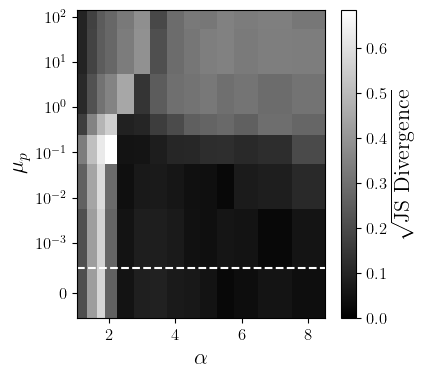

In [13]:
X, Y = np.meshgrid(aspect_ratios, cofs) 
plot_data = np.sqrt(JS_divergence[:, 0, :])
vmax_val = np.nanmax(plot_data)

# --- 2. Create the plot ---
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# Use pcolormesh for non-uniform grids
im = ax.pcolormesh(X, Y, plot_data, 
                   cmap='gray', 
                   vmin=0, 
                   vmax=vmax_val,
                   shading='auto') # 'shading' is important

# --- 3. Set the y-axis to 'symlog' ---
ax.set_yscale('symlog', linthresh=0.001)
ax.axhline(y=0.0005, color='white', linestyle='--', linewidth=1.5)  # Example threshold line
# --- 4. Add labels and colorbar ---
cbar = fig.colorbar(im, ax=ax)
# Make sure the label matches the data you're plotting
cbar.set_label(r'$\sqrt{\mathrm{JS\;Divergence}}$', fontsize=16) 
ax.set_xlabel(r'$\alpha$', fontsize=16)
ax.set_ylabel(r'$\mu_p$', fontsize=16)
fig.savefig(f"js_divergence_p4_Is_{Is[0]}.pdf", dpi=300, bbox_inches='tight')
# ax.set_title('JS Divergence between Measured PDF and Self-Consistent P2+P4 ODF', fontsize=18)

U_experimental self consistent: [4.48641904 5.70109597 7.09517206]


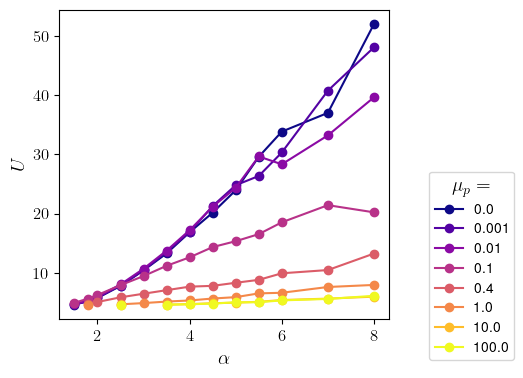

In [14]:
# plot the biaxiality as a function of aspect ratio for different cof and Is
cmap = plt.cm.plasma
num_cofs = len(cofs)

# U_experimental = np.array([1.2512, 4.108, 5.747])
alpha_experimental= np.array([2.0, 3.3, 5.0])
phi_experimental = np.array([0.495, 0.5, 0.48])
S2_experimental = np.array([0.27, 0.72, 0.81])

U_experimental = np.array([find_U_from_S2(s2) for s2 in S2_experimental])
print("U_experimental self consistent:", U_experimental)

for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(6,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    eccentricity = np.sqrt(1 - 1 / aspect_ratios**2)   
    volume = 4*np.pi*aspect_ratios/3 
   
    for i_cof, cof_val in enumerate(cofs):
        phi_dense = phis[i_cof, i_I, :] 
        plt.plot(
            # eccentricity,
            aspect_ratios,
            U1_self_consistents[i_cof, i_I, :],
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )

        # fir alpha **2parabola
        def parabola_fit(alpha, a, b, c):
            return a * alpha**b + c

    plt.xlabel(f"$\\alpha$")
    plt.ylabel("$U $")#\\phi$")
    plt.legend(title="$\\mu_p=$", bbox_to_anchor=(1.4, 0.5), fontsize=10)
    plt.tight_layout()
    plt.show()

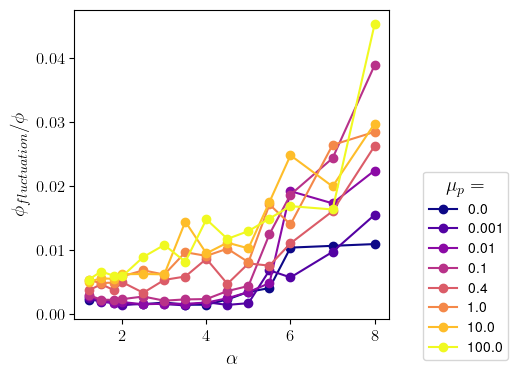

In [15]:
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(6,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    eccentricity = np.sqrt(1 - 1 / aspect_ratios**2)   
    volume = 4*np.pi*aspect_ratios/3 
   
    for i_cof, cof_val in enumerate(cofs):
        phi_dense = phis[i_cof, i_I, :] 
        plt.plot(
            # eccentricity,
            aspect_ratios,
            phi_fluctuations[i_cof, i_I, :] / phis[i_cof, i_I, :],
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )

    plt.xlabel(f"$\\alpha$")
    plt.ylabel("$\\phi_{fluctuation}/\\phi$")
    plt.legend(title="$\\mu_p=$", bbox_to_anchor=(1.4, 0.5), fontsize=10)
    plt.tight_layout()
    plt.show()

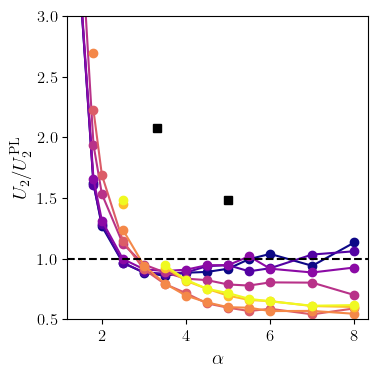

In [16]:
U1_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
U2_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))

colors_cof = cmap(np.linspace(0, 1, num_cofs))
cmap = mcolors.ListedColormap(colors_cof)

for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    eccentricity = np.sqrt(1 - 1 / aspect_ratios**2)   
    volume = 4*np.pi*aspect_ratios/3 
    # volume_excluded = -second_coeff_excluded_volume(eccentricity)
    volume_excluded = parsons_volume_approx_p2(aspect_ratios)
    volume_excluded_p4 = parsons_volume_approx_p4(aspect_ratios)


    for i_cof, cof_val in enumerate(cofs):
        phi_dense = phis[i_cof, i_I, :] 
        number_density = phi_dense / volume
        correction_density = compute_correction_density(phi_dense)
        U1_theoretical[i_cof, i_I, :] = volume_excluded * correction_density * 1.08
        U2_theoretical[i_cof, i_I, :] = volume_excluded_p4 * correction_density * 1.08
        plt.plot(
            # eccentricity,
            aspect_ratios,
            U1_self_consistents[i_cof, i_I, :] / U1_theoretical[i_cof, i_I, :],
            # U2_self_consistents[i_cof, i_I, :] / U2_theoretical[i_cof, i_I, :],
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )

    
    correction_density_experimental = phi_experimental * (1-3/4*phi_experimental) / (1-phi_experimental)**2
    volume_excluded_experimental = -excluded_volume_rod(alpha_experimental)
    plt.plot(
        alpha_experimental,
        U_experimental / (volume_excluded_experimental * correction_density_experimental),
        's',
        label='Experimental data',
        color='black'
    )

    norm = mcolors.Normalize(vmin=-0.5, vmax=num_cofs - 0.5)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

    # 3. Create the colorbar and place ticks exactly at the integer centers
    cbar = plt.colorbar(sm, ax=ax, ticks=np.arange(num_cofs), orientation='vertical', 
                        fraction=0.05, pad=0.02)

    # 4. Replace the integer labels with your actual 'cofs' values
    cbar.ax.set_yticklabels([str(c) for c in cofs])
    cbar.set_label(r'$\mu_p$', fontsize=16)
    cbar.ax.tick_params(labelsize=12)

    # 5. Draw the "dots" between 0.0 (index 0) and 0.001 (index 1)
    # y=0.5 is exactly halfway between the first two ticks.
    # cbar.ax.text(0.5, 0.5, '...', transform=cbar.ax.transData, 
    #             ha='center', va='center', fontsize=20, rotation=90, 
    #             bbox=dict(boxstyle='square,pad=0.2', fc='white', ec='none'))

    
    plt.xlabel(f"$\\alpha$")
    plt.ylabel("$U_2 / U_2^{{\\mathrm{PL}}}$")
    plt.axhline(1.0, color='k', linestyle='--', linewidth=1.5, label="Excluded volume")
    plt.ylim(0.5, 3.0)
    plt.tight_layout()
    # plt.savefig(f"U_fitted_scaled_vs_alpha.pdf", dpi=300, bbox_inches='tight')
    plt.show()

In [17]:
U2_theoretical

array([[[7.03995854e-04, 1.80604447e-02, 7.23829932e-02, 1.29490537e-01,
         3.25482875e-01, 5.66686985e-01, 8.26118485e-01, 1.08883564e+00,
         1.35253986e+00, 1.61136229e+00, 1.87740479e+00, 2.09567189e+00,
         2.59330409e+00, 3.07605275e+00]],

       [[7.05128371e-04, 1.80406023e-02, 7.25033070e-02, 1.29580373e-01,
         3.26261401e-01, 5.66352054e-01, 8.26098227e-01, 1.08875205e+00,
         1.35527957e+00, 1.61689570e+00, 1.85845062e+00, 2.11693150e+00,
         2.59992338e+00, 3.03701091e+00]],

       [[7.15393904e-04, 1.80803294e-02, 7.24183069e-02, 1.29367122e-01,
         3.24870821e-01, 5.63938113e-01, 8.17992226e-01, 1.08053019e+00,
         1.33625673e+00, 1.58853372e+00, 1.83843425e+00, 1.98599579e+00,
         2.47107372e+00, 2.86492131e+00]],

       [[6.59985444e-04, 1.64080303e-02, 6.55935275e-02, 1.16554880e-01,
         2.83980514e-01, 4.78081870e-01, 6.73928441e-01, 8.62208407e-01,
         1.04119882e+00, 1.20140862e+00, 1.34074456e+00, 1.480178

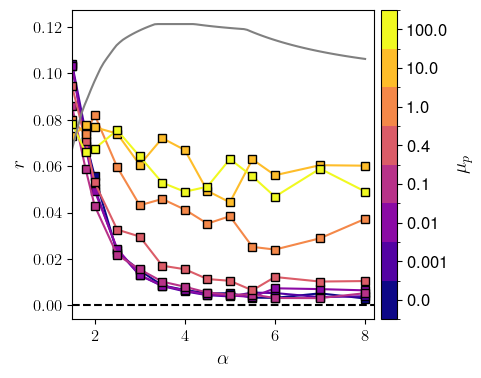

In [18]:
alphas_rods_experiments = np.array([2.0, 3.3,5.0]) #from alignment and dynamics Soft matter 2012

biaxiality_data_rods_experiments = np.array([0.21, 0.12, 0.09]) #taken from shear zone core 10-30
biaxiality_data_rods_experiments *= 2/3 # to convert to biaxiality as defined here

theta_d_rods_experiments = np.array([10.1, 8.0, 6.3])
# theta_d_rods_experiments = np.deg2rad(theta_d_rods_experiments)  # Convert degrees to radians

cmap = plt.cm.plasma
for i_I, I_val in enumerate(Is):
    fig = plt.figure(figsize=(5,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    
    for i_cof, cof_val in enumerate(cofs):
        plt.plot(
            aspect_ratios,
            biaxiality[i_cof, i_I, :],
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='s',
            markeredgecolor='black'
        )
    
    # Plot Jeffrey's prediction
    plt.plot(alpha_lin, biaxiality_talbot, '-', color='gray', label="Jeffrey's prediction")

    # Plot experimental data
    # plt.plot(alphas_rods_experiments, biaxiality_data_rods_experiments, 's', color='black', label='Experiments (rods)')

    cmap_discrete = mcolors.ListedColormap(colors_cof)

    bounds = np.arange(len(cofs) + 1)
    norm = mcolors.BoundaryNorm(bounds, cmap_discrete.N)

    sm = cm.ScalarMappable(cmap=cmap_discrete, norm=norm)
    sm.set_array([]) # Required for matplotlib <= 3.1, safe to leave in

    cbar = fig.colorbar(sm, ax=plt.gca(), pad=0.02)

    cbar.set_ticks(np.arange(len(cofs)) + 0.5)
    cbar.set_ticklabels([str(val) for val in cofs])
    cbar.set_label("$\\mu_p$")

    plt.xlabel("$\\alpha$")
    plt.ylabel("$r$")
    plt.axhline(0.0, color='k', linestyle='--', linewidth=1.5, label="Uniaxial limit")
    plt.tight_layout()
    plt.xlim(1.5, 8.2)
    plt.savefig(f"biaxiality_vs_alpha_I_{I_val}.pdf", dpi=300, bbox_inches='tight')
    plt.show()



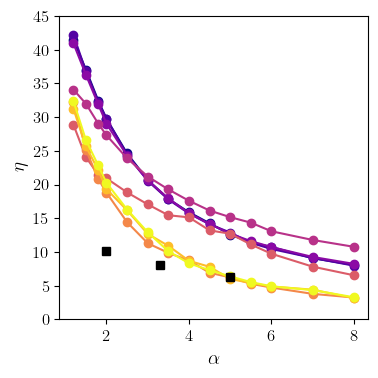

In [19]:
# print theta_D wrt the paramenters
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    

    for i_cof, cof_val in enumerate(cofs):
        theta_shifted = np.where(theta_d[i_cof, i_I, :] < 0, theta_d[i_cof, i_I, :] + np.pi, theta_d[i_cof, i_I, :])
        plt.plot(
            aspect_ratios,
            theta_shifted*180/np.pi,
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )
      
    # Plot experimental data
    plt.plot(alphas_rods_experiments, theta_d_rods_experiments, 's', color='black', label='Experiments (rods)')


    # plt.title(f"Shear angle vs α for I = {I_val}")
    plt.xlabel("$\\alpha$")
    plt.ylabel("$\\eta$")
    # plt.legend(title="$\\mu_p =$", bbox_to_anchor=(1.1, 1.0), fontsize=10)
    # plt.grid(True)
    plt.ylim([0., 45])
    plt.tight_layout()
    plt.savefig(f"theta_d_vs_alpha_I_{I_val}.svg", dpi=300, bbox_inches='tight')
    plt.show()



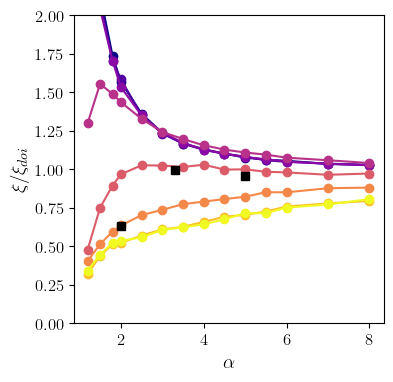

In [20]:
# derive lambda from theta_d and beta and plot it as a fucntion of alpha for the different parameters

# print theta_D wrt the paramenters
for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    
    for i_cof, cof_val in enumerate(cofs):

        c = np.tan(theta_d[i_cof, i_I, :])**2
        ell = (+1 + c) / (1-c)
        beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
        nematic_factor = (2+S2_scalar[i_cof, i_I, :])/(3*S2_scalar[i_cof, i_I, :])
        lambda_derived = nematic_factor
        eccentricity = np.sqrt(1 - 1 / aspect_ratios**2)
        plt.plot(
            aspect_ratios,
            # ell/beta,
            ell/lambda_derived,
            label=f"{cof_val}",
            color=colors[i_cof],
            marker='o'
        )
    
        doi_theory_lambda = beta*(2 + S2_scalar[i_cof, i_I, :]) 

    # plot experimental data
    eccentricity_experimental = np.sqrt(1 - 1 / alphas_rods_experiments**2)
    c_experimental = np.tan(np.deg2rad(theta_d_rods_experiments))**2
    ell_experimental = (+1 + c_experimental) / (1-c_experimental)
    beta_experimental = (alphas_rods_experiments**2 - 1) / (alphas_rods_experiments**2 + 1)
    nematic_factor_experimental = (2+S2_experimental)/(3*S2_experimental)
    lambda_derived_experimental = beta_experimental * nematic_factor_experimental
    plt.plot(
        alphas_rods_experiments,
        # ell_experimental/beta_experimental,
        ell_experimental/lambda_derived_experimental,
        's',
        color='black',
        label='Experiments (rods)'
    )    
    

    # plt.title(f"Ericksen number vs epsilon for I = {I_val}")
    plt.xlabel("$\\alpha$")
    plt.ylabel("$\\xi / \\xi_{doi}$")
    # plt.legend(title="$\\mu_p =$")
    # plt.grid(True)
    plt.ylim([0., 2])
    # plt.tight_layout()
    plt.savefig(f"ericksen_number_vs_epsilon_I_{I_val}.svg", dpi=300, bbox_inches='tight')
    plt.show()



alpha=1.2, S2=0.237, lambda_doi=3.150, lambda_higher=0.340
alpha=1.5, S2=0.485, lambda_doi=1.709, lambda_higher=0.442
alpha=1.8, S2=0.653, lambda_doi=1.354, lambda_higher=0.543
alpha=2.0, S2=0.724, lambda_doi=1.254, lambda_higher=0.603
alpha=2.5, S2=0.844, lambda_doi=1.123, lambda_higher=0.717
alpha=3.0, S2=0.897, lambda_doi=1.076, lambda_higher=0.793
alpha=3.5, S2=0.925, lambda_doi=1.054, lambda_higher=0.843
alpha=4.0, S2=0.944, lambda_doi=1.040, lambda_higher=0.877
alpha=4.5, S2=0.954, lambda_doi=1.032, lambda_higher=0.901
alpha=5.0, S2=0.962, lambda_doi=1.026, lambda_higher=0.919
alpha=5.5, S2=0.970, lambda_doi=1.020, lambda_higher=0.933
alpha=6.0, S2=0.974, lambda_doi=1.018, lambda_higher=0.943
alpha=7.0, S2=0.977, lambda_doi=1.016, lambda_higher=0.957
alpha=8.0, S2=0.984, lambda_doi=1.011, lambda_higher=0.967
alpha=1.2, S2=0.241, lambda_doi=3.099, lambda_higher=0.334
alpha=1.5, S2=0.489, lambda_doi=1.695, lambda_higher=0.440
alpha=1.8, S2=0.647, lambda_doi=1.364, lambda_higher=0.5

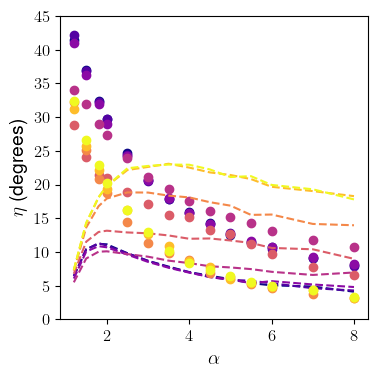

In [21]:
# compare the director angle predicted by doi theory to the measured one

theta_doi = np.zeros_like(theta_d)
for i_cof, cof_val in enumerate(cofs[:]):
    for i_I, I_val in enumerate(Is):
        for i_alpha, alpha_val in enumerate(aspect_ratios):
            beta = (alpha_val**2 - 1) / (alpha_val**2 + 1)
            S2 = S2_scalar[i_cof, i_I, i_alpha]
            nematic_factor = (2 + S2) / (3 * S2)
            lambda_doi =  nematic_factor
            lambda_higher = beta * (6 + S2 + 8 * S2**2) / (15 * S2)
            print(f"alpha={alpha_val}, S2={S2:.3f}, lambda_doi={lambda_doi:.3f}, lambda_higher={lambda_higher:.3f}")
            theta_doi[i_cof, i_I, i_alpha] = beta * np.arctan( np.sqrt( (lambda_doi - 1) / (lambda_doi + 1) ) )
            # theta_doi[i_cof, i_I, i_alpha] = np.arctan( np.sqrt( (lambda_higher - 1) / (lambda_higher + 1) ) )


for i_I, I_val in enumerate(Is):
    plt.figure(figsize=(4,4))
    colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]
    
    for i_cof, cof_val in enumerate(cofs[:]):
        theta_shifted_measured = np.where(theta_d[i_cof, i_I, :] < 0, theta_d[i_cof, i_I, :] + np.pi, theta_d[i_cof, i_I, :])
        theta_shifted_doi = np.where(theta_doi[i_cof, i_I, :] < 0, theta_doi[i_cof, i_I, :] + np.pi, theta_doi[i_cof, i_I, :])
        plt.plot(
            aspect_ratios,
            theta_shifted_measured*180/np.pi,
            label=f"Measured $\\mu_p={cof_val}$",
            color=colors[i_cof],
            marker='o', 
            linestyle= 'none'
        )
        plt.plot(
            aspect_ratios,
            theta_shifted_doi*180/np.pi,
            label=f"DOI Theory $\\mu_p={cof_val}$",
            color=colors[i_cof],
            linestyle='--'
        )
    
    # plt.title(f"Shear angle vs α for I = {I_val}")
    plt.xlabel("$\\alpha$")
    plt.ylabel("$\\eta$ (degrees)")
    plt.ylim([0., 45])
    # plt.legend(bbox_to_anchor=(1.05, 1.0), fontsize=10)
    plt.tight_layout()
    # plt.savefig(f"theta_doi_vs_measured_vs_alpha_I_{I_val}.png", dpi=300, bbox_inches='tight')
    plt.show()



/tmp/ipykernel_10320/3714939363.py:154: RuntimeWarning: divide by zero encountered in divide
  first_factor = 15 / 32 / x**4
/tmp/ipykernel_10320/3714939363.py:155: RuntimeWarning: divide by zero encountered in arctanh
  second_factor = x**2 - 3 + (x**2+3) * (1 - x**2) * np.arctanh(x) / x
/tmp/ipykernel_10320/3714939363.py:155: RuntimeWarning: invalid value encountered in multiply
  second_factor = x**2 - 3 + (x**2+3) * (1 - x**2) * np.arctanh(x) / x
/tmp/ipykernel_10320/3714939363.py:155: RuntimeWarning: invalid value encountered in divide
  second_factor = x**2 - 3 + (x**2+3) * (1 - x**2) * np.arctanh(x) / x
/tmp/ipykernel_10320/3714939363.py:157: RuntimeWarning: divide by zero encountered in divide
  (4 * x**2 - 3)*np.arcsin(x) / (x * np.sqrt(1 - x**2))
/tmp/ipykernel_10320/3714939363.py:157: RuntimeWarning: invalid value encountered in divide
  (4 * x**2 - 3)*np.arcsin(x) / (x * np.sqrt(1 - x**2))


Text(0.5, 1.0, 'Second coefficient of excluded volume as a function of eccentricity')

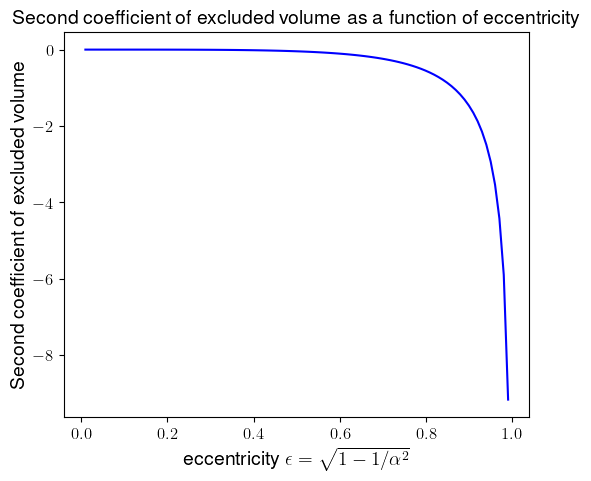

In [22]:
x = np.linspace(0, 1, 100)
plt.figure(figsize=(6, 5))
plt.plot(x, second_coeff_excluded_volume(x), label='Second coefficient of excluded volume', color='blue')
plt.xlabel('eccentricity $\\epsilon = \\sqrt{1 - 1 / \\alpha^2}$')
plt.ylabel('Second coefficient of excluded volume')
plt.title('Second coefficient of excluded volume as a function of eccentricity')


Text(0.5, 1.0, 'Eccentricity as a function of aspect ratio')

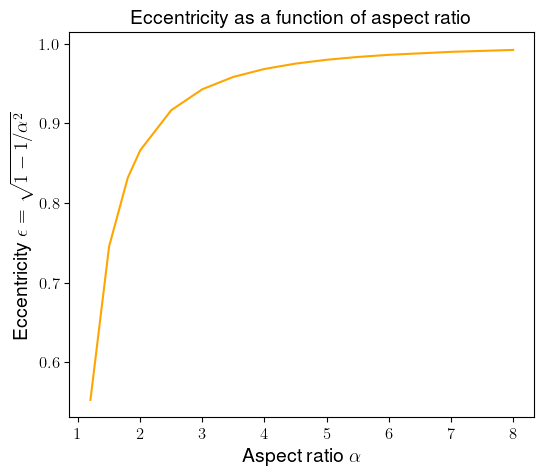

In [23]:
plt.figure(figsize=(6, 5))
plt.plot(aspect_ratios, eccentricity, label='Eccentricity', color='orange')
plt.xlabel('Aspect ratio $\\alpha$')
plt.ylabel('Eccentricity $\\epsilon = \\sqrt{1 - 1 / \\alpha^2}$')
plt.title('Eccentricity as a function of aspect ratio')

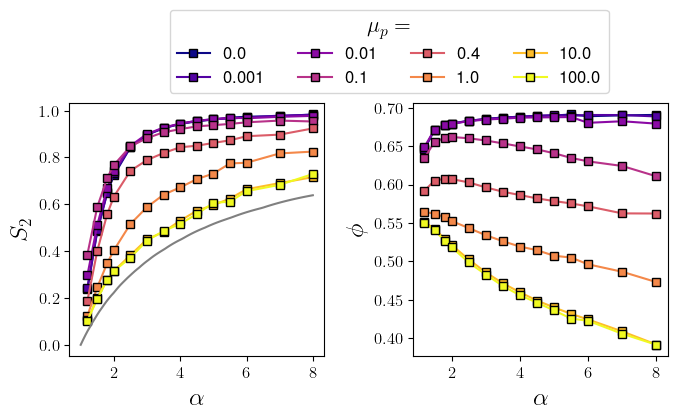

In [24]:
# plot phi as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 2, figsize=(7,4*7/8))
for i_cof, cof_val in enumerate(cofs):
    ax[1].plot(
        aspect_ratios,
        phis[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='s',
        markeredgecolor='black',
    )
    ax[0].plot(
        aspect_ratios,
        S2_scalar[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='s',
        markeredgecolor='black',
    )

# ax[0].plot(alpha_experimental, S2_experimental, 's', label=None, color='black')
# ax[1].plot(alpha_experimental, phi_experimental, 's', label=None, color='black')
ax[0].set_xlabel(f"$\\alpha$", fontsize=18)
ax[0].set_ylabel("$S_2$", fontsize=18)
ax[0].plot(alpha_lin, S2_talbot, '-', color='gray', label="Jeffrey's prediction")
# ax[0].axhline(0.0, color='k', linestyle='--', linewidth=1.5)
ax[1].set_xlabel(f"$\\alpha$", fontsize=18)
ax[1].set_ylabel("$\\phi$", fontsize=18)
fig.tight_layout()
# plt.axhline(0.0, color='k', linestyle='--', linewidth=1.5, label="Isotropic")
plt.legend(title="$\\mu_p=$", bbox_to_anchor=(0.8, 1.4), fontsize=12, ncols=4, title_fontsize=16)
plt.savefig(f"S2_phi_vs_alpha_I_{I}.svg", dpi=300, bbox_inches='tight')

In [25]:
for i, alpha in enumerate(aspect_ratios):
    print("alpha:", alpha, "phis:", phis[:, 0, i])

alpha: 1.2 phis: [0.64569509 0.64597508 0.64848567 0.63432245 0.59154729 0.56433376
 0.55151121 0.54994126]
alpha: 1.5 phis: [0.67135911 0.67117781 0.67154052 0.65524969 0.60516404 0.5621198
 0.54210769 0.54025293]
alpha: 1.8 phis: [0.67708598 0.67735608 0.67716532 0.66075718 0.60742164 0.55755757
 0.52956195 0.5270791 ]
alpha: 2.0 phis: [0.67920776 0.67932    0.67905339 0.6618238  0.60706825 0.55257552
 0.52136092 0.51859462]
alpha: 2.5 phis: [0.68260462 0.68298794 0.68230236 0.66012156 0.60277077 0.54339526
 0.50264077 0.49868484]
alpha: 3.0 phis: [0.68527907 0.68518478 0.68450291 0.6572542  0.59626409 0.53411577
 0.48579437 0.48296945]
alpha: 3.5 phis: [0.6871266  0.68712271 0.68555444 0.65350033 0.59069016 0.52628262
 0.47158802 0.46809142]
alpha: 4.0 phis: [0.68816907 0.68815692 0.68695504 0.64950941 0.58628506 0.51932646
 0.45987005 0.45601519]
alpha: 4.5 phis: [0.68915654 0.68947595 0.68723928 0.64569105 0.58199239 0.51463237
 0.44913649 0.44647434]
alpha: 5.0 phis: [0.68970948 

Slope (frictionless): -2.208793452800351, Intercept: -0.13836576104361037
Slope (frictional): -1.4108553992639903, Intercept: -0.7767665525246067
Power law fit parameters frictional: a = 0.4917967224356915, b = -1.3050231792388276


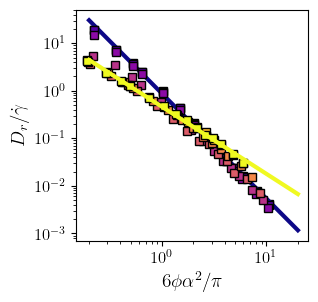

In [26]:
# Power law model: y = a * x^b
def power_law(x, a, c):
    return a *x**c

cmap = plt.cm.plasma
colors = [cmap(i / (num_cofs - 1)) for i in range(num_cofs)]

n_ell_fit = np.linspace(2*10**(-1), 2*10**1, 100)

# plot the D_r over shear rate as function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
Dr_theoretical = np.zeros((len(cofs), len(Is), len(aspect_ratios)))
max_nell = 0
for i_cof, cof_val in enumerate(cofs):
    V_p = 4 * np.pi * aspect_ratios / 3  # particle volume for prolate ellipsoid
    n_ell3 = phis[i_cof, 0, :] / V_p *aspect_ratios**3
    nem_param = S2_scalar[i_cof, 0, :]
    correction_end_end_contact = (1 + np.pi/aspect_ratios) + (2*np.pi/aspect_ratios - 1) * nem_param**2

    max_nell = max(max_nell, np.max(n_ell3))

    ax.loglog(
        n_ell3[:],
        D_r[i_cof, 0, :] * correction_end_end_contact[:]**2/shear_rates[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors[i_cof],
        markeredgecolor='black',
    )

    log_nell3 = np.log(n_ell3[:])  # Exclude first three points to avoid low-n_ell deviations
    log_Dr_over_shear = np.log(D_r[0, 0, :] * correction_end_end_contact[:]**2 / shear_rates[0, 0, :])

    if cof_val == 0.0:
        # Fit the data
        slope, intercept = np.polyfit(log_nell3, log_Dr_over_shear, 1)
        print(f"Slope (frictionless): {slope}, Intercept: {intercept}")

        popt, _ = spo.curve_fit(
            power_law,
            n_ell3[3:],
            D_r[0, 0, 3:] * correction_end_end_contact[3:]**2 / shear_rates[0, 0, 3:],
            p0=[0,0]  # Initial guess for a and b
        )

        # plot fit performed in log log scale
        ax.loglog(
           n_ell_fit,
           np.exp(intercept) * np.exp(slope * np.log(n_ell_fit)),
           '-',
           label='Power law fit (frictionless)',
           linewidth=3,
           color=colors[i_cof]
        )              

    
    if cof_val == 100.0:
        popt_frictional, _ = spo.curve_fit(
            power_law,
            n_ell3[:],
            D_r[i_cof, 0, :] * correction_end_end_contact[:]**2 / shear_rates[i_cof, 0, :],
            p0=[0,0]  # Initial guess for a and b
        )
        slope_frictional, intercept_frictional = np.polyfit(log_nell3, np.log(D_r[i_cof, 0, :] * correction_end_end_contact[:]**2 / shear_rates[i_cof, 0, :]), 1)
        print(f"Slope (frictional): {slope_frictional}, Intercept: {intercept_frictional}")
    
        ax.loglog(
            n_ell_fit,  
            np.exp(intercept_frictional) * np.exp(slope_frictional * np.log(n_ell_fit)),
            '-',
            label='Power law fit (frictional)',
            linewidth=3,
            color=colors[i_cof],
            markeredgecolor='black',
          )
    Dr_theoretical[i_cof, 0, :] = power_law(n_ell3, *popt) * shear_rates[i_cof, 0, :] / correction_end_end_contact**2


correction_end_end_contact = (1 + np.pi/aspect_ratios) + (2*np.pi/aspect_ratios - 1) * S2_scalar[0,0,:]**2
# ax.plot(n_ell_fit, power_law(n_ell_fit, *popt), '--', label='Power law fit (frictionless)', linewidth=3, color=colors[0])
# ax.plot(n_ell_fit, power_law(n_ell_fit, *popt_frictional), ':', label='Power law fit (frictional)', linewidth=3, color=colors[-1])

# Plot

# print(f"Power law fit parameters: a = {popt[0]}, b = {popt[1]}")
print(f"Power law fit parameters frictional: a = {popt_frictional[0]}, b = {popt_frictional[1]}")

ax.set_xlabel("$6 \\phi \\alpha^2 / \\pi$")
ax.set_ylabel("$D_{r}/ \\dot \\gamma$")
fig.savefig(f"D_r_over_shear_vs_n_ell3_I_{I}.svg", dpi=300, bbox_inches='tight')

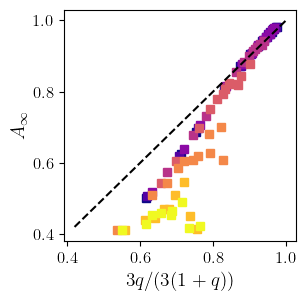

In [27]:
# plot the D_r over shear rate as function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
for i_cof, cof_val in enumerate(cofs):
    q_chen = U1_self_consistents[i_cof, 0, :] / 3 * S2_scalar[i_cof, 0, :] * (S2_scalar[i_cof, 0, :] + 0.5)
    ax.plot(
        (3 * q_chen + 1) / (3 * (1 + q_chen)), 
        A_infty[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors[i_cof]
    )

ax.plot([0.42, 1], [0.42, 1], '--', color='black', label='y=x')

ax.set_xlabel("$3 q / (3(1+q))$")
ax.set_ylabel("$A_{\\infty}$")
fig.savefig(f"A_infty_I_{I}.pdf", dpi=300, bbox_inches='tight')

In [28]:
q_chen.shape

(14,)

In [29]:
U1_self_consistents.shape

(8, 1, 14)

In [30]:
U1_self_consistents.shape

(8, 1, 14)

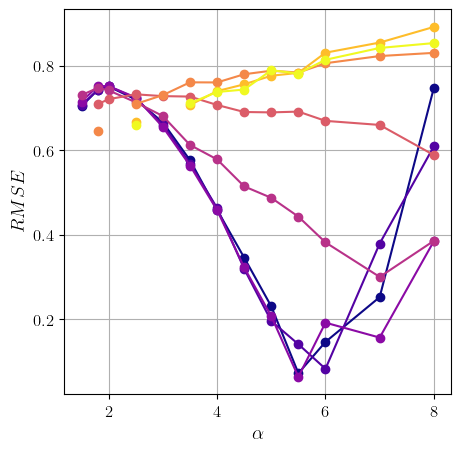

In [31]:
# plot rmse as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
for i_cof, cof_val in enumerate(cofs):
    ax.plot(
        aspect_ratios,
        rmse_self_consistents[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )

ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel("$RMSE$")
ax.grid(True)
plt.savefig(f"rmse_vs_alpha_I_{I}.png", dpi=300, bbox_inches='tight')


Cof=0.0: Slope of log-log plot (power-law exponent) = 1.18
Cof=0.001: Slope of log-log plot (power-law exponent) = 1.19
Cof=0.01: Slope of log-log plot (power-law exponent) = 1.24
Cof=0.1: Slope of log-log plot (power-law exponent) = 1.15
Cof=0.4: Slope of log-log plot (power-law exponent) = 1.21
Cof=1.0: Slope of log-log plot (power-law exponent) = 1.41
Cof=10.0: Slope of log-log plot (power-law exponent) = 1.36
Cof=100.0: Slope of log-log plot (power-law exponent) = 1.39


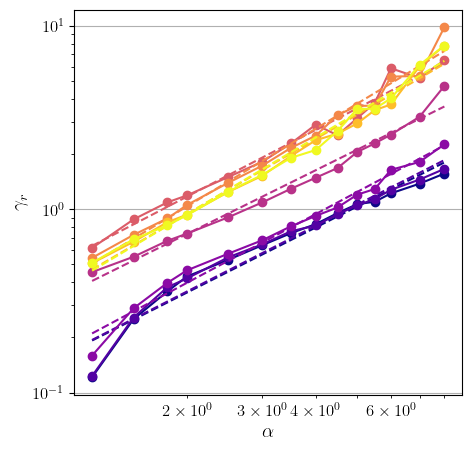

In [32]:
# plot rmse as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
gamma_r = shear_rates * tau_r
for i_cof, cof_val in enumerate(cofs):
    ax.loglog(
        aspect_ratios,
        gamma_r[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )

    log_alpha = np.log(aspect_ratios)
    log_gamma_r = np.log(gamma_r[i_cof, 0, :])
    slope, intercept = np.polyfit(log_alpha, log_gamma_r, 1)
    print(f"Cof={cof_val}: Slope of log-log plot (power-law exponent) = {slope:.2f}")

    ax.loglog(
        aspect_ratios,
        np.exp(intercept) * aspect_ratios**slope,
        linestyle='--',
        color=colors[i_cof],
        label=f"Fit Cof={cof_val} (slope={slope:.2f})"
    )
    

ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel(r"$\gamma_r$")
ax.grid(True)
# plt.savefig(f"gamma_r_vs_alpha_I_{I}.png", dpi=300, bbox_inches='tight')


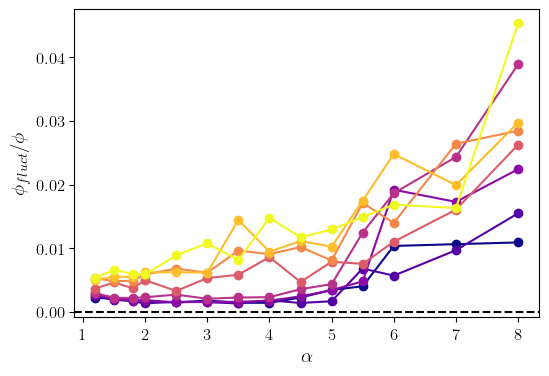

In [33]:
# plot fluctuations of phi as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for i_cof, cof_val in enumerate(cofs):
    ax.plot(
        aspect_ratios,
        phi_fluctuations[i_cof, 0, :]/phis[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors[i_cof],
        marker='o'
    )
ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel("$\\phi_{fluct}/\\phi$")
ax.axhline(0.0, color='k', linestyle='--', linewidth=1.5)


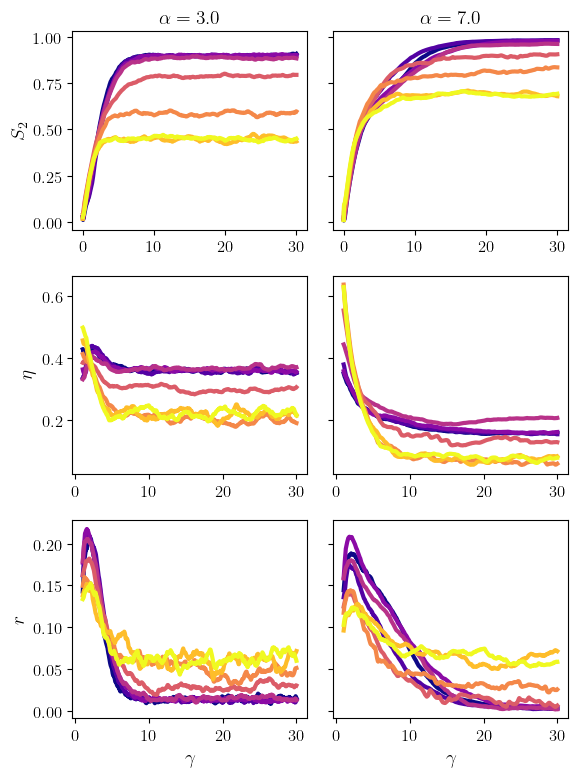

In [34]:
# plot s2 over time for a fixd alpha and different cofs
alpha_indexs = [5, 12]
alpha_values = aspect_ratios[alpha_indexs]

cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]


fig, ax = plt.subplots(3, len(alpha_values), figsize=(3*len(alpha_values), 8), sharey='row')
for i, alpha_index in enumerate(alpha_indexs):
    for i_cof, cof_val in enumerate(cofs):
        # remove trailing zeros to arrays
        gamma = strains[i_cof, 0, alpha_index, :]
        S2_t = S2_over_time[i_cof, 0, alpha_index, :]
        biaxiality_t = biaxiality_over_time[i_cof, 0, alpha_index, :]
        eta = angle_over_time[i_cof, 0, alpha_index, :]

        gamma = np.where(gamma != 0, gamma, np.nan)  # Replace zeros with NaN for better plotting
        S2_t = np.where(S2_t != 0, S2_t, np.nan)  # Replace zeros with NaN for better plotting
        eta = np.where(eta != 0, eta, np.nan)
        biaxiality_t = np.where(biaxiality_t != 0, biaxiality_t, np.nan)

        ax[0][i].plot(
            gamma,
            S2_t,
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            linewidth = 3, 
            # marker='o'
        )

        ax[1][i].plot(
            gamma[100:],
            eta[100:],
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            linewidth = 3, 
            # marker='o'
        )

        ax[2][i].plot(
            gamma[100:],
            biaxiality_t[100:],
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            linewidth = 3, 
            # marker='o'
        )


    ax[0, i].set_title(f"$\\alpha = {alpha_values[i]}$")
    ax[2, i].set_xlabel("$\\gamma$")

ax[0, 0].set_ylabel("$S_2$")
ax[1, 0].set_ylabel("$\\eta$")
# ax[2, 0].set_ylabel("$\\lambda_2 - \\lambda_3$")
ax[2, 0].set_ylabel("$r$")
fig.tight_layout()
fig.savefig(f"S2_over_time_vs_gamma_alpha.pdf", dpi=600, bbox_inches='tight')

<>:53: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_10320/491269776.py:53: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_ylabel("$\langle [\mathbf{u}(\\gamma) \cdot \mathbf{u}(0)]^2  \\rangle  $")


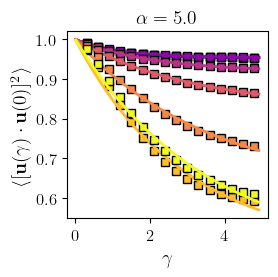

In [35]:
# plot oacf over time

def model_decay(t, tau_r, A_infty):
    return A_infty + (1 - A_infty) * np.exp(-t / tau_r)

alpha_indexs = [9]
alpha_values = aspect_ratios[alpha_indexs]

cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]
n_plots = len(alpha_indexs)
fig, ax = plt.subplots(1, n_plots, figsize=(3*n_plots, 3), sharey=True)

if n_plots == 1:
    ax = [ax]

for i, alpha_index in enumerate(alpha_indexs):
    for i_cof, cof_val in enumerate(cofs): #(cofs):
        # remove trailing zeros to arrays
        i_cof = np.where(cofs == cof_val)[0][0]

        t = times[i_cof, 0, alpha_index, :]
        gamma = shear_rates[i_cof, 0, alpha_index] * t
        corr = oacf[i_cof, 0, alpha_index, :]

        t = np.where(t != 0, t, np.nan)  # Replace zeros with NaN for better plotting
        corr = np.where(corr != 0, corr, np.nan)  # Replace zeros with NaN for better plotting
        gamma = np.where(gamma != 0, gamma, np.nan)

        ax[i].plot(
            # t[::30],
            gamma[::30],
            corr[::30],
            's',
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            markeredgecolor='black'
            # linewidth = 2, 
        )
        # plot the fitted model
        ax[i].plot(
            gamma, 
            model_decay(gamma/shear_rates[i_cof, 0, alpha_index], tau_r[i_cof, 0, alpha_index], A_infty[i_cof, 0, alpha_index]),
            color=colors_cof[i_cof],
            linestyle='-',
            linewidth=2,
        )

    ax[i].set_title(f"$\\alpha = {alpha_values[i]}$")
    # ax[i].set_xlabel("$t$")
    ax[i].set_xlabel("$\\gamma$")

ax[0].set_ylabel("$\langle [\mathbf{u}(\\gamma) \cdot \mathbf{u}(0)]^2  \\rangle  $")
fig.tight_layout()
fig.savefig(f"oacf_vs_time_alpha.svg", dpi=300, bbox_inches='tight')


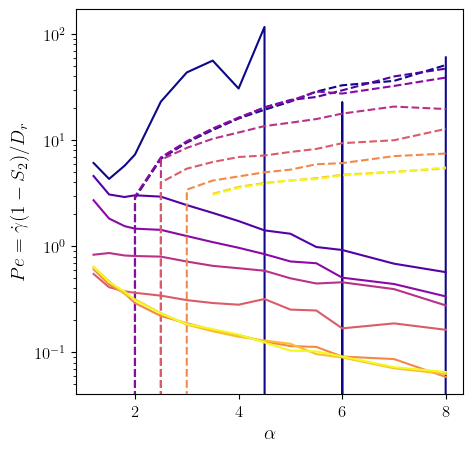

In [36]:
cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]

# plot the Peclet number with the measured D_rn
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
    Pe = - (D_r[i_cof, 0, :]) / omega[i_cof, 0, :, 2] 
    Pi = U1_self_consistents[i_cof, 0, :] * S2_scalar_theoretical[i_cof, 0, :]
    ax.plot(
        aspect_ratios,
        Pe,
        '-',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )
    ax.plot(
        aspect_ratios,
        Pi,
        '--',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )

# ax.set_xlabel(f"$\\alpha$")]

ax.set_xlabel("$\\alpha$")
ax.set_ylabel(r"$Pe= \dot \gamma (1-S_2)/ D_r$")
ax.set_yscale('log')
# ax.set_ylim(0, 100)
fig.savefig(f"Pe_vs_alpha_I_{I}.png", dpi=300, bbox_inches='tight')

Text(0, 0.5, '$r$')

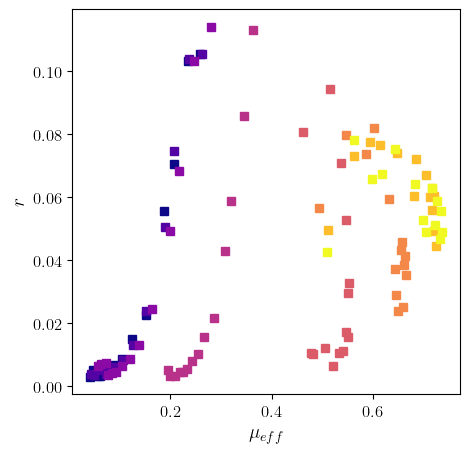

In [37]:
cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]

# plot the Peclet number with the measured D_rn
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
    effective_friction = p_xy[i_cof, 0, :] / p_yy[i_cof, 0, :]
    shear_at_angle = beta* np.sin(2 *theta_d[i_cof, 0, :]) 
    nematic_screening = 2 / 3 * (1-S2_scalar[i_cof, 0, :])
    ax.plot(
        p_xy[i_cof, 0, :] / p_yy[i_cof, 0, :],
        biaxiality[i_cof, 0, :],
        # biaxiality[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )
# ax.set_xlabel(f"$\\alpha$")
ax.set_xlabel("$\\mu_{eff}$")
ax.set_ylabel(r"$r$")
# ax.set_yscale('log')
# ax.set_ylim(0, 100)
# fig.savefig(f"Pe_vs_alpha_I_{I}.png", dpi=300, bbox_inches='tight')

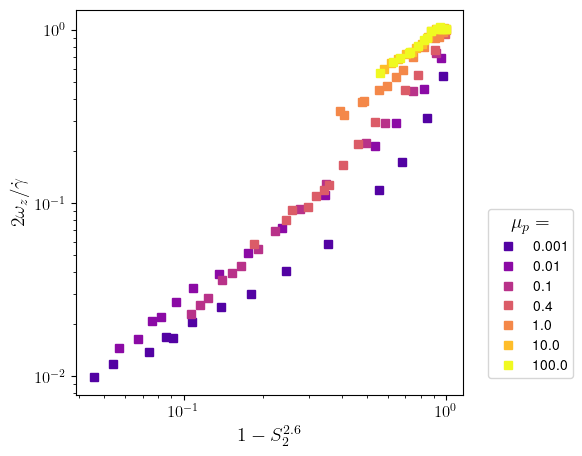

In [38]:
cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]

# plot the Peclet number with the measured D_rn
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
    if i_cof <= 0.0:
        continue
    Pe = shear_rates[i_cof, 0, :] / (D_r[i_cof, 0, :])
    shear_at_angle = beta* np.sin(2 *theta_d[i_cof, 0, :]) 
    nematic_screening = 2 / 3 * (1-S2_scalar[i_cof, 0, :])
    ax.loglog(
        1-S2_scalar[i_cof, 0, :]**2.6,
        # shear_rates[i_cof, 0, :],
        # D_r[i_cof, 0, :],
        # -omega[i_cof, 0, :, 2] / (1-S2_scalar[i_cof, 0, :]**2.6),
        - 2 * omega[i_cof, 0, :, 2] / shear_rates[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )
# ax.set_xlabel(f"$\\alpha$")
ax.set_xlabel("$1-S_{2}^{2.6}$")
ax.set_ylabel(r"$2 \omega_z / \dot \gamma$")
ax.legend(title ="$\\mu_p=$", bbox_to_anchor=(1.3, 0.5), fontsize=10)
# ax.set_yscale('log')
# ax.set_ylim(0.007, 1.2)
fig.savefig(f"pol_scaling_dimensionless_no_mup0.pdf", dpi=300, bbox_inches='tight')

Text(0.5, 0, '$U S_2$')

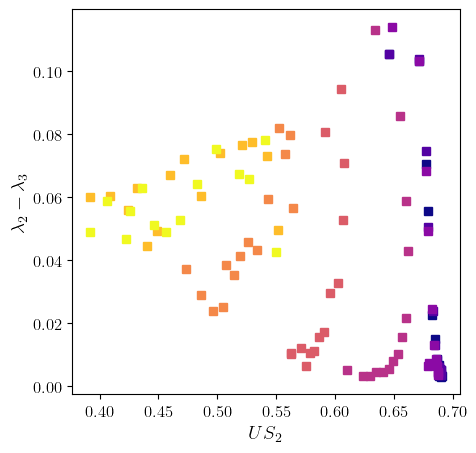

In [39]:
cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]

# plot the Peclet number with the measured D_rn
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
    Pe = shear_rates[i_cof, 0, :] / (D_r[i_cof, 0, :])
    shear_at_angle = beta* np.sin(2 *theta_d[i_cof, 0, :]) 
    nematic_screening = 2 / 3 * (1-S2_scalar[i_cof, 0, :])
    ax.plot(
        #U1_self_consistents[i_cof, 0, :]* S2_scalar_theoretical[i_cof, 0, :],
        phis[i_cof, 0, :],
        biaxiality[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )
# ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel(r"$ \lambda_2 - \lambda_3 $")
ax.set_xlabel(r"$U S_2$")

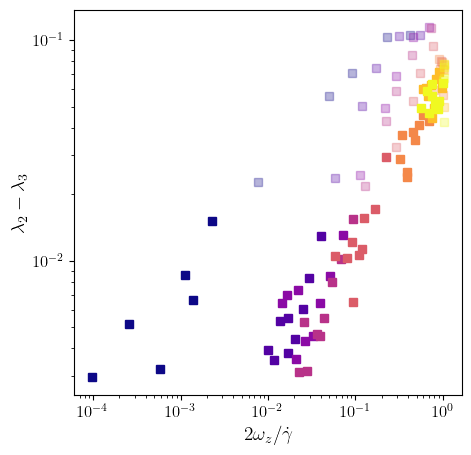

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
    Pe = shear_rates[i_cof, 0, :] / (D_r[i_cof, 0, :])
    shear_at_amgle = beta* np.sin(2 *theta_d[i_cof, 0, :]) 

    ax.loglog(
        -2*omega[i_cof, 0, 5:, 2]/shear_rates[i_cof, 0, 5:], 
        biaxiality[i_cof, 0, 5:],  # factor 3 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )

    ax.loglog(
        -2*omega[i_cof, 0, :5, 2] /shear_rates[i_cof, 0, :5], 
        biaxiality[i_cof, 0, :5],  # factor 3 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof], 
        alpha=0.3
    )
# ax.set_xlabel(f"$\\alpha$")
ax.set_xlabel("$2\\omega_z/ \\dot\\gamma$")
ax.set_ylabel("$\\lambda_2- \\lambda_3$")
# ax.axhline(0.5, color='k', linestyle='--', linewidth=1.5, label="Maximum biaxiality")
# plt.xlim(0.001, 3.0)
# ax.set_ylim(0, 100)
fig.savefig(f"biaxiality_vs_omega.pdf", dpi=300, bbox_inches='tight')

Text(0, 0.5, '$r$')

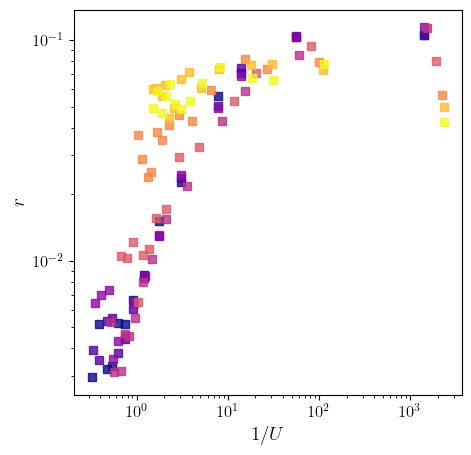

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
    Pe = shear_rates[i_cof, 0, :] / (D_r[i_cof, 0, :])
    shear_at_amgle = beta* np.sin(2 *theta_d[i_cof, 0, :]) 

    ax.loglog(
        1 / (U2_theoretical[i_cof, 0, :]), 
        biaxiality[i_cof, 0, :], 
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof], 
        alpha=0.8
    )
# ax.set_xlabel(f"$\\alpha$")
ax.set_xlabel("$1/ U$")
ax.set_ylabel("$r$")

In [42]:
S2_scalar_theoretical[S2_scalar_theoretical <0] = 0.0
S4_scalar_theoretical[S4_scalar_theoretical <0] = 0.0


Text(0, 0.5, '$r$')

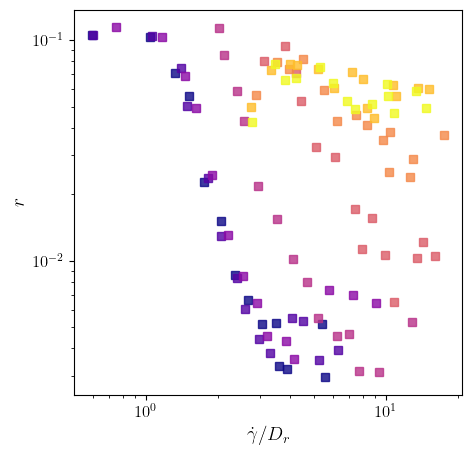

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
    Pe = shear_rates[i_cof, 0, :] / (D_r[i_cof, 0, :])
    shear_at_amgle = beta* np.sin(2 *theta_d[i_cof, 0, :]) 

    ax.loglog(
        shear_rates[i_cof, 0, :] * (1-S2_scalar[i_cof, 0, :])**1 /D_r[i_cof, 0, :],
        biaxiality[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof], 
        alpha=0.8
    )
# ax.set_xlabel(f"$\\alpha$")
ax.set_xlabel(r"$\dot \gamma/ D_r$")
ax.set_ylabel("$r$")

Text(0, 0.5, '$D_r/ \\dot \\gamma$')

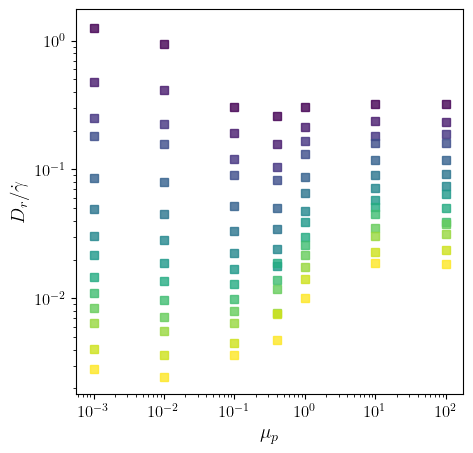

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
cmap = plt.cm.viridis
colors_alpha = [cmap(i / (len(aspect_ratios) - 1)) for i in range(len(aspect_ratios))]
for i_alpha, alpha_val in enumerate(aspect_ratios):
    
    ax.loglog(
        cofs,
        D_r[:, 0, i_alpha] / shear_rates[:, 0, i_alpha],
        's',
        label=f"{cof_val}",
        color=colors_alpha[i_alpha], 
        alpha=0.8
    )
# ax.set_xlabel(f"$\\alpha$")
ax.set_xlabel(r"$\mu_p$")
ax.set_ylabel(r"$D_r/ \dot \gamma$")

<>:13: SyntaxWarning: invalid escape sequence '\g'
<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\g'
<>:14: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_10320/2663788384.py:13: SyntaxWarning: invalid escape sequence '\g'
  ax.set_xlabel("$\gamma_{{r}}$")
/tmp/ipykernel_10320/2663788384.py:14: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel("$2 \omega / \dot \gamma$")


Text(0, 0.5, '$2 \\omega / \\dot \\gamma$')

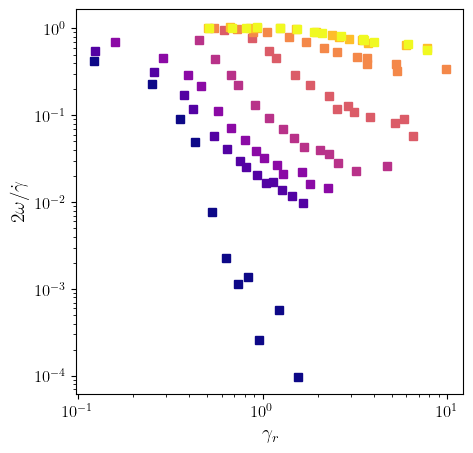

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
   
    ax.loglog(
        gamma_r[i_cof, 0, :],
        -2 *omega[i_cof, 0, :, 2] / shear_rates[i_cof, 0, :] ,
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )
# ax.set_xlabel(f"$\\alpha$")
ax.set_xlabel("$\gamma_{{r}}$")
ax.set_ylabel("$2 \omega / \dot \gamma$")
# plt.ylim(0.01, 1.2)

<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_10320/1257228261.py:20: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel("$2\omega_z /\dot\gamma \\sqrt{1-\\beta^2}$")


Text(0, 0.5, '$2\\omega_z /\\dot\\gamma \\sqrt{1-\\beta^2}$')

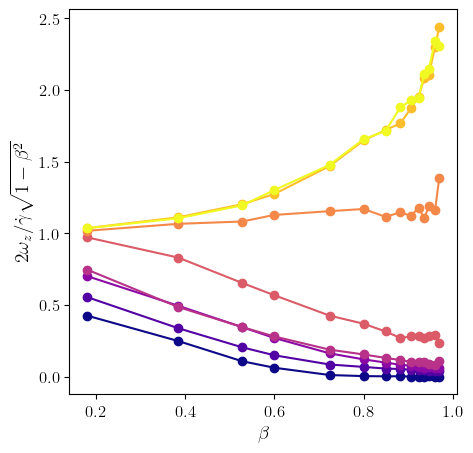

In [46]:
# plot rmse as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

screening_omega = np.zeros((len(cofs), 1, len(aspect_ratios)))

for i_cof, cof_val in enumerate(cofs):
    
    screening_omega[i_cof, 0, :] = - 2*omega[i_cof, 0, :, 2] / shear_rates[i_cof, 0, :]  / np.sqrt(1 - beta**2)
    beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
    ax.plot(
        beta,
        screening_omega[i_cof, 0, :],
        # - 2*omega[i_cof, 0, :, 2] * shear_rates[i_cof, 0, :]/ D_r[i_cof, 0, :], 
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        marker='o'
    )
    
ax.set_xlabel(f"$\\beta$")
ax.set_ylabel("$2\omega_z /\dot\gamma \\sqrt{1-\\beta^2}$")
# ax.set_ylabel("$2\omega_z / D_r \dot\gamma $")
# ax.grid(True)
# plt.savefig(f"omega_vs_alpha_I_{I}.svg", dpi=300, bbox_inches='tight')


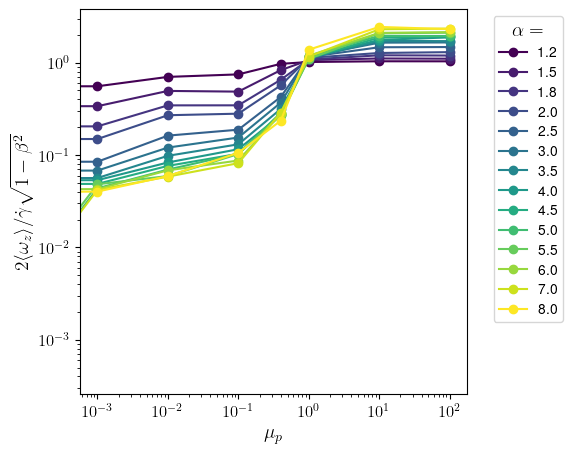

In [47]:
# plot rmse as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

cmap_alpha = plt.cm.viridis
colors_alpha = [cmap_alpha(i / (len(aspect_ratios) - 1)) for i in range(len(aspect_ratios))]

for i_alpha, alpha_val in enumerate(aspect_ratios):

    ax.loglog(
        np.array(cofs) ,
        screening_omega[:, 0, i_alpha],
        label=f"{alpha_val}",
        color=colors_alpha[i_alpha],
        marker='o'
    )
    
ax.set_xlabel(f"$\\mu_p$")
ax.set_ylabel("$2 \\langle \\omega_z \\rangle / \\dot\\gamma \\sqrt{1-\\beta^2}$")
# ax.set_xlim(-0.01, 0.1)
ax.legend(title="$\\alpha=$", bbox_to_anchor=(1.05, 1.0), fontsize=10)


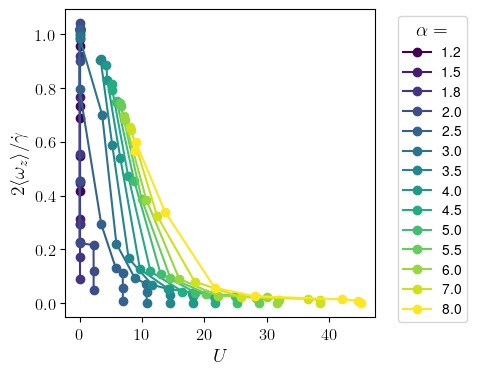

In [48]:
# plot rmse as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

cmap_alpha = plt.cm.viridis
colors_alpha = [cmap_alpha(i / (len(aspect_ratios) - 1)) for i in range(len(aspect_ratios))]

for i_alpha, alpha_val in enumerate(aspect_ratios):

    ax.plot(
        U1_theoretical[:, 0, i_alpha] * S2_scalar_theoretical[:, 0, i_alpha],
        -2 * omega[:, 0, i_alpha, 2] / shear_rates[:, 0, i_alpha] ,
        # - 2*omega[i_cof, 0, :, 2] * shear_rates[i_cof, 0, :]/ D_r[i_cof, 0, :], 
        label=f"{alpha_val}",
        color=colors_alpha[i_alpha],
        marker='o'
    )
    
ax.set_xlabel(f"$U$")
ax.set_ylabel("$2 \\langle \\omega_z \\rangle / \\dot\\gamma $")
# ax.set_xlim(-0.01, 0.1)
# ax.set_ylim(0.005, 2,)
ax.legend(title="$\\alpha=$", bbox_to_anchor=(1.05, 1.0), fontsize=10)
fig.savefig(f"omega_vs_U1_mup_all.pdf", dpi=300, bbox_inches='tight')


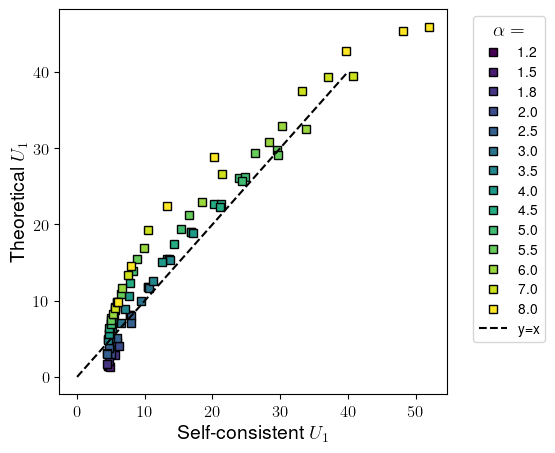

In [49]:
# plot theroetical U vs self consistent U
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
cmap_alpha = plt.cm.viridis
colors_alpha = [cmap_alpha(i / (len(aspect_ratios) - 1)) for i in range(len(aspect_ratios))]
for i_alpha, alpha_val in enumerate(aspect_ratios):

    ax.plot(
        U1_self_consistents[:, 0, i_alpha],
        U1_theoretical[:, 0, i_alpha],
        's',
        label=f"{alpha_val}",
        color=colors_alpha[i_alpha],
        markeredgecolor='black'
    )
ax.set_xlabel(f"Self-consistent $U_1$")
ax.set_ylabel(f"Theoretical $U_1$")
ax.plot([0.0, 40], [0.0, 40], '--', color='black', label='y=x')
ax.legend(title="$\\alpha=$", bbox_to_anchor=(1.05, 1.0), fontsize=10)
fig.savefig(f"U1_self_consistent_vs_theoretical.pdf", dpi=300, bbox_inches='tight')

<>:137: SyntaxWarning: invalid escape sequence '\m'
<>:137: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_10320/3598539560.py:137: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('$\mu_p$', fontsize=18)


Starting individual fits (4-parameter model)...


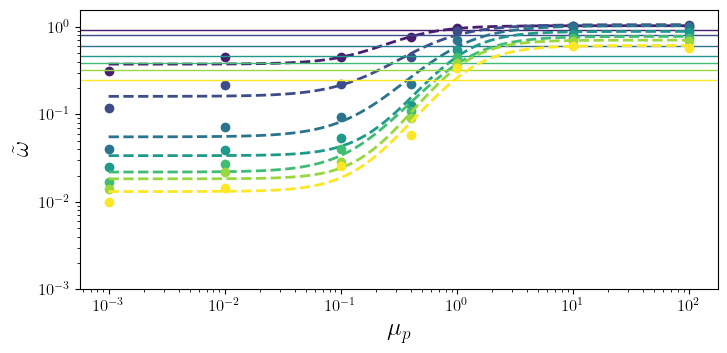


--- All Fit Parameters [A, B, mu_c, k] ---
Alpha  1.2: [0.511, 1.052, 0.065, 0.564]
Alpha  1.5: [0.376, 1.032, 0.315, 1.790]
Alpha  1.8: [0.225, 1.040, 0.466, 1.595]
Alpha  2.0: [0.161, 1.061, 0.556, 1.591]
Alpha  2.5: [0.082, 1.056, 0.753, 1.602]
Alpha  3.0: [0.055, 1.031, 0.887, 1.630]
Alpha  3.5: [0.040, 0.943, 0.994, 1.669]
Alpha  4.0: [0.034, 0.888, 1.014, 1.945]
Alpha  4.5: [0.027, 0.830, 1.051, 1.868]
Alpha  5.0: [0.022, 0.779, 1.079, 1.739]
Alpha  5.5: [0.019, 0.767, 1.240, 1.671]
Alpha  6.0: [0.018, 0.706, 1.058, 2.004]
Alpha  7.0: [0.014, 0.665, 1.160, 1.894]
Alpha  8.0: [0.013, 0.613, 1.210, 1.861]


In [50]:
from scipy.optimize import curve_fit

# --- 1. Define the 5-Parameter Model for a single alpha ---
def simplified_model(mu_p, A, B, mu_c, k):
    """
    Fits the data for a single, fixed alpha.
    y = (1-S) * A + S * B
    
    Parameters to fit:
    A:    Screening plateau (low mu_p)
    B:    Gearing plateau (high mu_p)
    mu_c: Critical friction
    k:    Steepness of switch
    """
    
    mu_p_safe = mu_p + 1e-9
    mu_c_safe = mu_c + 1e-9
    
    screening_state = A
    gearing_state = B  # Simplified: gearing state is a plateau
    
    # Numerically stable switch
    mu_ratio = mu_p_safe / mu_c_safe
    switch = 1.0 / (1.0 + mu_ratio**(-k))
    
    return (1.0 - switch) * screening_state + switch * gearing_state

def simplified_model_k_fixed(mu_p, A, B, mu_c):
    """
    Fits the data for a single, fixed alpha.
    y = (1-S) * A + S * B
    
    Parameters to fit:
    A:    Screening plateau (low mu_p)
    B:    Gearing plateau (high mu_p)
    mu_c: Critical friction
    k:    Steepness of switch fixed at 2.5
    """
    
    mu_p_safe = mu_p + 1e-9
    mu_c_safe = mu_c + 1e-9
    
    screening_state = A
    gearing_state = B  # Simplified: gearing state is a plateau
    
    # Numerically stable switch
    mu_ratio = mu_p_safe / mu_c_safe
    switch = 1.0 / (1.0 + mu_ratio**(-1.75))
    
    return (1.0 - switch) * screening_state + switch * gearing_state

def log_model(mu_p, A, B, mu_c, k):
    return np.log(simplified_model(mu_p, A, B, mu_c, k))

def log_model_k_fixed(mu_p, A, B, mu_c):
    return np.log(simplified_model_k_fixed(mu_p, A, B, mu_c))


mu_p_values = cofs

all_fit_parameters = {}
error_bars = {}

plt.figure(figsize=(10*.75, 5*.75))
ax = plt.gca()
colors = plt.cm.viridis(np.linspace(0, 1, len(aspect_ratios)))

betas = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
y_data_2d = - 2 * omega[1:, 0, :, 2] / shear_rates[1:, 0, :] # / np.sqrt(1 - betas**2)
print("Starting individual fits (4-parameter model)...")

# --- 4. Loop, Fit, and Plot ---
for i_alpha, alpha_val in enumerate(aspect_ratios[:]):
    
    x_data_fit = mu_p_values[1:]
    y_data_fit = np.log(y_data_2d[:, i_alpha])
    
    # --- Perform the Fit ---
    # Guesses [A, B, mu_c, k]
    A_guess = max(y_data_fit[0], 1e-9)
    B_guess = max(y_data_fit[-1], 1e-9)

    # bounds = ([1e-9, 1e-9, 1e-9], [np.inf, np.inf, 5.0]) 
    # p0 = [A_guess, B_guess, 0.5]
    
    # Bounds for A must be positive
    bounds = ([1e-9, 1e-9, 1e-9, 1e-9], [np.inf, np.inf, 5.0, 10.0]) 
    p0 = [A_guess, B_guess, 0.5, 2.5]
    
    
    try:
        popt, pcov = curve_fit(
            log_model,
            # log_model,
            x_data_fit,
            y_data_fit,
            p0=p0,
            bounds=bounds,
            maxfev=5000
        )
        all_fit_parameters[alpha_val] = popt
        perr = np.sqrt(np.diag(pcov))
        error_bars[alpha_val] = perr
        
        mu_fit_line = np.logspace(-3, np.log10(mu_p_values.max()), 100)
        y_vals_fit = log_model(mu_fit_line, *popt)
        # y_vals_fit = log_model(mu_fit_line, *popt)


    except RuntimeError as e:
        print(f"Fit failed for alpha = {alpha_val:.2f}: {e}")
        all_fit_parameters[alpha_val] = [np.nan] * 4
    
    if (i_alpha+1)%2 == 0:
        # Plot original data
        ax.plot(
            x_data_fit, 
            np.exp(y_data_fit), 
            'o', 
            color=colors[i_alpha], 
            label=f"${alpha_val:.1f}$"
        )
        ax.plot(mu_fit_line, np.exp(y_vals_fit), '--', color=colors[i_alpha], linewidth=2)

        # plot jeffrey theory value
        omega_jeffrey =  np.sqrt(1 - betas[i_alpha]**2)
        ax.axhline(
            omega_jeffrey,
            color=colors[i_alpha],
            linestyle='-',
            linewidth=1.0
        )

# --- 5. Finalize Plot ---
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$\mu_p$', fontsize=18)
# ax.set_ylabel(r'$-2\langle\omega\rangle / \dot{\gamma}$', fontsize=18)
ax.set_ylabel(r'$\tilde{\omega}$', fontsize=18)
ax.set_ylim(0.001, y_data_2d.max()*1.5)

plt.tight_layout()
plt.savefig("omega_fit_vs_mu_p.png", dpi=300, bbox_inches='tight', transparent=True)
# plt.xlim(0, 0.01)
plt.show()

# --- 6. Print Stored Parameters ---
print("\n--- All Fit Parameters [A, B, mu_c, k] ---")
for alpha_val, params in all_fit_parameters.items():
    param_str = ", ".join([f"{p:.3f}" for p in params])
    print(f"Alpha {alpha_val:4.1f}: [{param_str}]")

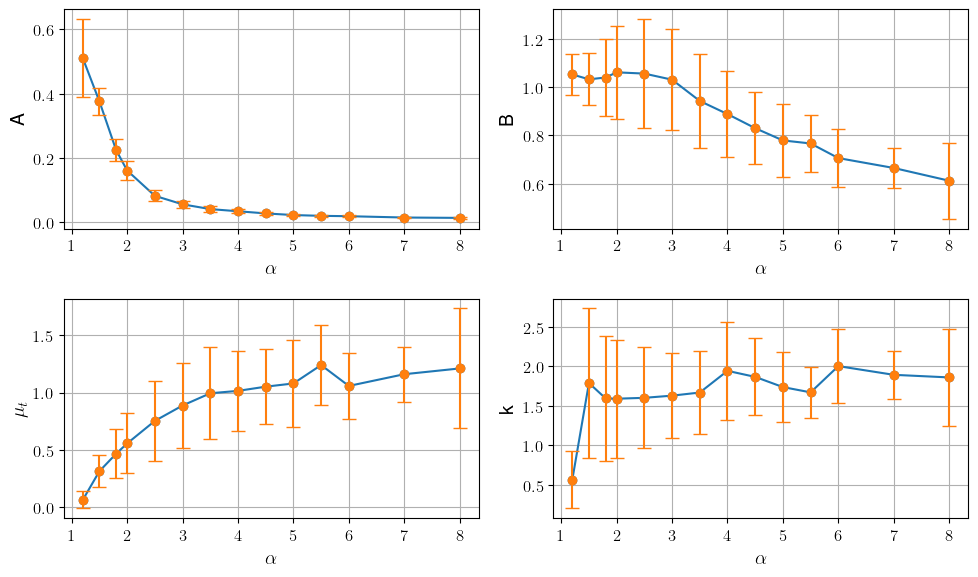

In [51]:
# plot fitted parameters as a function of aspect ratio
fig, ax = plt.subplots(2, 2, figsize=(10, 6))
for i, param_name in enumerate(['A', 'B', r'$\mu_t$', 'k']):
# for i, param_name in enumerate(['A', 'B']):
    ax_i = ax[i // 2, i % 2]
    param_values = [all_fit_parameters[alpha][i] for alpha in aspect_ratios[:]]
    betas = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
    ax_i.plot(
        aspect_ratios[:],
        # betas[1:],
        param_values,
        'o-'
    )

    # add error bars
    error_values = [error_bars[alpha][i] for alpha in aspect_ratios[:]]
    ax_i.errorbar(
        aspect_ratios[:],
        param_values,
        yerr=error_values,
        fmt='o',
        capsize=5,
        # color='blue'
    )

    ax_i.set_xlabel('$\\alpha$')
    ax_i.set_ylabel(param_name)
    ax_i.grid(True)

plt.tight_layout()
plt.savefig("fit_parameters_vs_alpha.pdf", dpi=300, bbox_inches='tight')

In [52]:
all_fit_parameters_array = np.array(
    [all_fit_parameters[alpha] for alpha in aspect_ratios[:]]
)
print("Fit parameters array shape:", all_fit_parameters_array.shape)
# print("average k value over alphas:", np.nanmean(all_fit_parameters_array[:, 3]))

Fit parameters array shape: (14, 4)


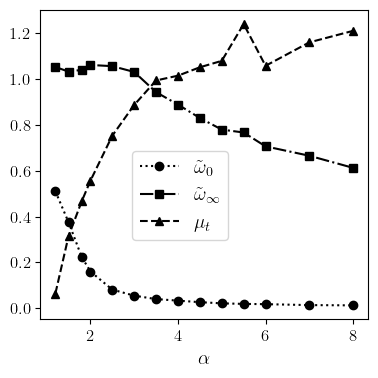

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4), sharex=True)

list_linestyle = [':', '-.', '--']
list_markers = ['o', 's', '^']

for i, param_name in enumerate([r'$\tilde{\omega}_0$', r'$\tilde{\omega}_\infty$', r'$\mu_t$']):
# for i, param_name in enumerate(['A', 'B']):
    param_values = [all_fit_parameters[alpha][i] for alpha in aspect_ratios[:]]
    betas = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
    ax.plot(
        aspect_ratios[:],
        # betas[1:],
        param_values,
        'k',
        linestyle = list_linestyle[i],
        marker = list_markers[i],
        label=param_name
    )

    # add error bars
    error_values = [error_bars[alpha][i] for alpha in aspect_ratios[:]]
    ax_i.errorbar(
        aspect_ratios[:],
        param_values,
        yerr=error_values,
        fmt='o',
        color ='k',
        capsize=5,
        # color='blue'
    )

    ax_i.set_xlabel('$\\alpha$')
    ax_i.set_ylabel(param_name)
    ax_i.grid(True)

plt.xlabel('$\\alpha$')
plt.legend(loc='center left', bbox_to_anchor=(0.25, 0.4))
plt.tight_layout()
plt.savefig("fit_parameters_vs_alpha.pdf", dpi=300, bbox_inches='tight')

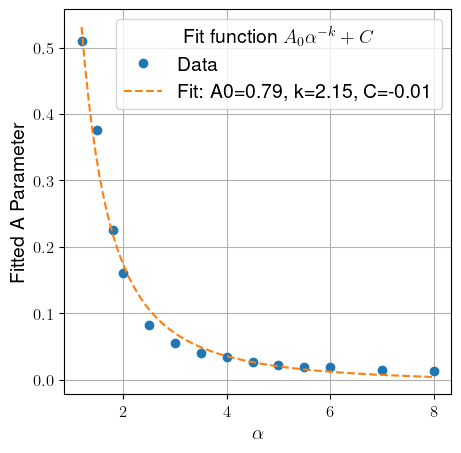

In [54]:
# fir the decay of A with alpha with an exponential function
def exponential_decay(x, A0, tau, C):
    return A0 * np.exp(-x / tau) + 0.0

def power_law_decay(x, A0, k, C):
    return A0 * x**(-k) + C

alpha_vals = aspect_ratios[:]
A_values = all_fit_parameters_array[:, 0]

popt_exp, pcov_exp = curve_fit(
    power_law_decay,
    alpha_vals[:],
    A_values[:],
    p0=[A_values[0], 5.0, 0.0]
)

# plot the fit
plt.figure(figsize=(5, 5))
plt.plot(
    alpha_vals,
    A_values,
    'o',
    label='Data'
)
alpha_fit = np.linspace(min(alpha_vals), max(alpha_vals), 100)
plt.plot(
    alpha_fit,
    power_law_decay(alpha_fit, *popt_exp),
    '--',
    label=f'Fit: A0={popt_exp[0]:.2f}, k={popt_exp[1]:.2f}, C={popt_exp[2]:.2f}'
)
plt.xlabel('$\\alpha$')
plt.ylabel('Fitted A Parameter')
plt.legend(title= "Fit function $A_0 \\alpha^{-k} + C$")
plt.grid(True)


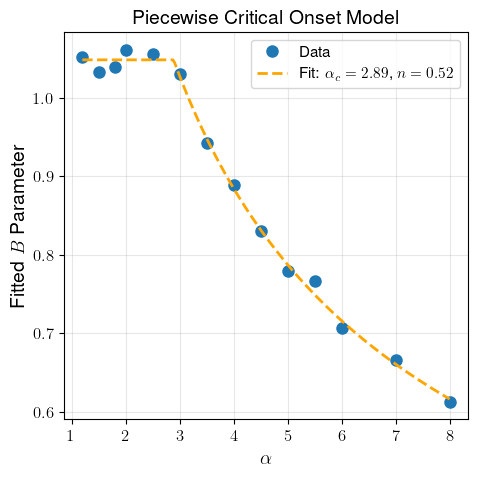

Plateau (B_max): 1.048
Critical Onset (alpha_c): 2.890
Decay Exponent (n): 0.522


In [55]:
def piecewise_power_law(x, B_max, alpha_c, n):
    # Create an array of the same shape as x filled with B_max
    y = np.full_like(x, B_max)
    
    # Find indices where alpha > alpha_c
    mask = x > alpha_c
    
    # Apply the power law decay only to those indices
    # Formula: B_max * (alpha / alpha_c)^(-n)
    # This ensures continuity at alpha = alpha_c (value becomes B_max * 1)
    y[mask] = B_max * (x[mask] / alpha_c)**(-n)
    
    return y

# 2. Setup Data (Assuming alpha_vals and all_fit_parameters_array exist)
# Use a fixed guess for B_max from the data plateau
B_max_guess = np.mean(all_fit_parameters_array[:3, 1]) 

# 3. Fit
popt, pcov = curve_fit(
    piecewise_power_law,
    alpha_vals,
    all_fit_parameters_array[:, 1],
    p0=[B_max_guess, 3.5, 1.0],   # Guess: Knee at 3.5, linear decay (n=1)
    bounds=([1.0, 2.0, 0.1],      # Lower bounds
            [1.2, 5.0, 5.0])      # Upper bounds
)

# 4. Plot
plt.figure(figsize=(5, 5))
plt.plot(alpha_vals, all_fit_parameters_array[:, 1], 'o', markersize=8, label='Data')

# Create a dense x-axis for the line so the "kink" looks sharp
x_fit = np.linspace(min(alpha_vals), max(alpha_vals), 200)
y_fit = piecewise_power_law(x_fit, *popt)

plt.plot(x_fit, y_fit, '--', linewidth=2, color='orange',
         label=f'Fit: $\\alpha_c={popt[1]:.2f}$, $n={popt[2]:.2f}$')

plt.xlabel(r'$\alpha$', fontsize=14)
plt.ylabel(r'Fitted $B$ Parameter', fontsize=14)
plt.title("Piecewise Critical Onset Model")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Plateau (B_max): {popt[0]:.3f}")
print(f"Critical Onset (alpha_c): {popt[1]:.3f}")
print(f"Decay Exponent (n): {popt[2]:.3f}")

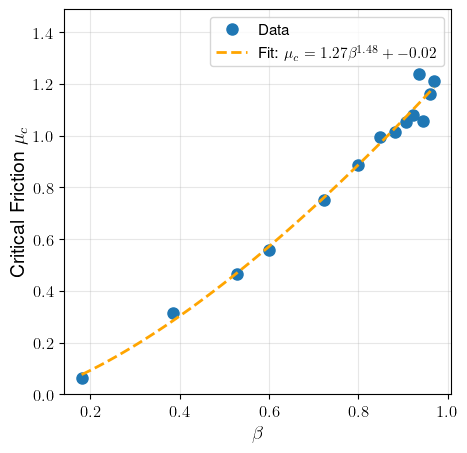

Exponent (k): 1.477


In [56]:
# 1. Define Power Law Model
def power_law(x, a, k, b):
    return a * x**k + b

mu_c_values = all_fit_parameters_array[:, 2]
beta_vals = (alpha_vals**2 - 1) / (alpha_vals**2 + 1)
beta_vals 
# 2. Fit with Bounds
# Constrain offset 'b' to be small (e.g., between -0.5 and 0.5)
# Constrain 'a' and 'k' to be positive
popt_pow, pcov_pow = curve_fit(
    power_law,
    beta_vals[:],
    # alpha_vals[:],
    mu_c_values[:],
    p0=[0.5, 0.5, 0.0],   # Guess: prefactor 0.5, sqrt scaling, zero offset
    # bounds=([0.0, 0.1, -0.5],   # Lower bounds
    #         [5.0, 3.0, 0.5]),   # Upper bounds (keep offset small!)
    maxfev=5000
)

# 3. Plot
plt.figure(figsize=(5, 5))
plt.plot(beta_vals, mu_c_values, 'o', markersize=8, label='Data')
# plt.plot(alpha_vals, mu_c_values, 'o', markersize=8, label='Data')


alpha_fit = np.linspace(min(alpha_vals), max(alpha_vals), 100)
beta_fit = np.linspace(min(beta_vals), max(beta_vals), 100)
plt.plot(
    # alpha_fit,
    beta_fit,
    power_law(beta_fit, *popt_pow),
    # power_law(beta_fit, *popt_pow),
    '--',
    linewidth=2,
    color='orange',
    # label=f'Fit: $\\mu_c = {popt_pow[0]:.2f} \\alpha^{{{popt_pow[1]:.2f}}} + {popt_pow[2]:.2f}$'
    label=f'Fit: $\\mu_c = {popt_pow[0]:.2f} \\beta^{{{popt_pow[1]:.2f}}} + {popt_pow[2]:.2f}$'
)

# plt.plot(beta_fit, beta_fit / np.sqrt(1-beta_fit**2), ':', color='gray', label=r'Theoretical: $\mu_c = \beta^2 / \sqrt{1-\beta^2}$')
plt.ylim(0, mu_c_values.max()*1.2)
plt.xlabel(r'$\beta$', fontsize=14)
plt.ylabel(r'Critical Friction $\mu_c$', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Exponent (k): {popt_pow[1]:.3f}")

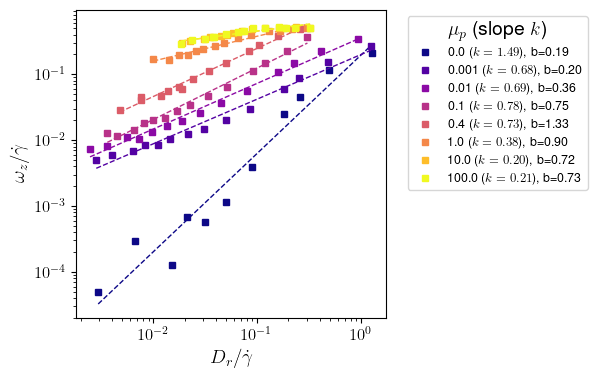

In [57]:
cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for i_cof, cof_val in enumerate(cofs):
    # Extract Data
    x_data = D_r[i_cof, 0, :] /shear_rates[i_cof, 0, :]
    y_data = -omega[i_cof, 0, :, 2] / shear_rates[i_cof, 0, :]
    
    # 1. Filter valid data for log (must be > 0)
    mask = (x_data > 0) & (y_data > 0)
    x_clean = x_data[mask]
    y_clean = y_data[mask]

    if len(x_clean) > 1:
        # 2. Log-transform data
        log_x = np.log10(x_clean)
        log_y = np.log10(y_clean)
        
        # 3. Perform linear fit in log-log space
        slope, intercept = np.polyfit(log_x, log_y, 1)
        
        k_fit = slope
        a_fit = 10**intercept
        
        # 4. Generate fit line for plotting
        x_fit_line = np.logspace(np.log10(x_clean.min()), np.log10(x_clean.max()), 100)
        y_fit_line = a_fit * x_fit_line**k_fit
        
        # Plot fit line
        ax.loglog(
            x_fit_line,
            y_fit_line,
            '--',
            color=colors_cof[i_cof], 
            linewidth=1.0,
            # label=f"k={k_fit:.2f}" # Optional: Label lines with slope
        )
        
        # Plot data points
        ax.loglog(
            x_clean,
            y_clean,
            's',
            label=f"{cof_val} ($k={k_fit:.2f}$), b={a_fit:.2f}",
            color=colors_cof[i_cof],
            markersize=5
        )
    else:
        print(f"Skipping index {i_cof}: Not enough positive data for log-fit.")

ax.set_ylabel(r"$\omega_z /\dot \gamma$")
ax.set_xlabel(r"$D_r/\dot \gamma$")

# Clean up legend
ax.legend(title="$\\mu_p$ (slope $k$)", fontsize=9, bbox_to_anchor=(1.05, 1.0), loc='upper left')

plt.show()

In [58]:
print("alpha_vals", alpha_vals)
print("mu_c_values", mu_c_values)

alpha_vals [1.2 1.5 1.8 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  7.  8. ]
mu_c_values [0.06467459 0.31454738 0.46606729 0.55634591 0.75285549 0.88687197
 0.99365313 1.01449334 1.05112038 1.07913421 1.23951619 1.05751872
 1.15971466 1.21004636]


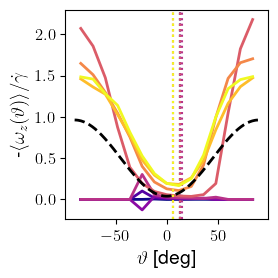

In [72]:
alpha_indexs = [9]
alpha_values = aspect_ratios[alpha_indexs]

cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]
n_plots = len(alpha_indexs)
fig, ax = plt.subplots(1, n_plots, figsize=(3*n_plots, 3), sharey=True)

if len(alpha_indexs) == 1:
    ax = [ax]  # Make ax iterable

for i, alpha_index in enumerate(alpha_indexs):
    for i_cof, cof_val in enumerate(cofs): #(cofs):
        # remove trailing zeros to arrays
        i_cof = np.where(cofs == cof_val)[0][0]

        thetas = theta_bins[i_cof, 0, alpha_index, :] * 180/np.pi
        omega_theta = omega_bins[i_cof, 0, alpha_index, :] / shear_rates[i_cof, 0, alpha_index]**2
        std_omega_theta = std_omega_bins[i_cof, 0, alpha_index, :] / shear_rates[i_cof, 0, alpha_index]
        ax[i].plot(
            thetas,
            -omega_theta,
            '-',
            label=f"{cof_val}",
            color=colors_cof[i_cof],
            linewidth = 2.0, 
        )
        # ax[i].errorbar(thetas, omega_theta, std_omega_theta, mfc=colors_cof[i_cof],mec=colors_cof[i_cof],
        #          ecolor=colors_cof[i_cof], fmt='o', capsize=5, linestyle='None', linewidth=0.5)
        theta_d[i_cof, 0, alpha_index] = theta_d[i_cof, 0, alpha_index] if theta_d[i_cof, 0, alpha_index] >0 else theta_d[i_cof, 0, alpha_index] + np.pi
        ax[i].axvline(theta_d[i_cof, 0, alpha_index]*180/np.pi, color=colors_cof[i_cof], linestyle=':', label="$\\eta$")


        # ax[i].set_ylim(-2.5, 0.2)
        
    beta = (alpha_values[i]**2 - 1) / (alpha_values[i]**2 + 1)
    theta_fit = np.linspace(-np.pi/2, np.pi/2, 200)
    jeffrey_omega = -(1 - beta * np.cos(2 * theta_fit)) / 2
    theta_fit = theta_fit * 180/np.pi

    ax[i].plot(
        theta_fit,
        -jeffrey_omega,
        'k--',
        label='Jeffrey',
        linewidth=2
    )

    # ax[i].set_title(f"$\\alpha = {alpha_values[i]}$")
    ax[i].set_xlabel("$\\vartheta$ [deg]")
    
ax[0].set_ylabel("-$\\langle \\omega_z(\\vartheta)   \\rangle  /\\dot \\gamma $")
fig.tight_layout()
fig.savefig(f"avg_omega_bin.pdf", dpi=300, bbox_inches='tight')


In [60]:
omega_bins_file = "omega_bins_data.npz"
np.savez(omega_bins_file,
         omega_bins=omega_bins,
         theta_bins=theta_bins,
         phis = phis, 
         theta_d = theta_d)

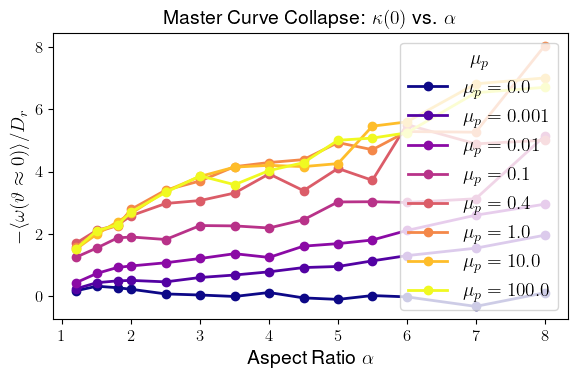

In [61]:
fig, ax = plt.subplots(figsize=(6, 4))
cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]

central_omega_norm = np.zeros((len(cofs), len(aspect_ratios)))

for i_cof, cof_val in enumerate(cofs):
    
    for alpha_index in range(len(aspect_ratios)):
        # Identify the central bin (closest to theta = 0)
        thetas = theta_bins[i_cof, 0, alpha_index, :]
        center_idx = np.argmin(np.abs(thetas)) 
        # Extract the user's dimensionless omega for the central bin
        # (Keeping your original shear_rates normalization)
        omega_theta = omega_bins[i_cof, 0, alpha_index, :] / shear_rates[i_cof, 0, alpha_index]
        central_omega = -omega_theta[center_idx]
        
        # Extract the corresponding rotational diffusion
        dr_val = D_r[i_cof, 0, alpha_index]
        
        # Calculate the pure geometric driving kappa(0)
        central_omega_norm[i_cof, alpha_index] = central_omega / dr_val
        
    # Plot the series for this specific friction coefficient
    ax.plot(
        aspect_ratios,
        central_omega_norm[i_cof, :],  
        marker='o', 
        linestyle='-',
        color=colors_cof[i_cof], 
        label=f"$\\mu_p = {cof_val}$",
        linewidth=2.0
    )

ax.set_xlabel("Aspect Ratio $\\alpha$")
ax.set_ylabel("$-\\langle \\omega(\\vartheta \\approx 0) \\rangle / D_r$")
ax.set_title("Master Curve Collapse: $\\kappa(0)$ vs. $\\alpha$")
ax.legend(title="$\\mu_p$")
fig.tight_layout()
# fig.savefig("central_bin_collapse_vs_alpha.pdf", dpi=300, bbox_inches='tight')
plt.show()

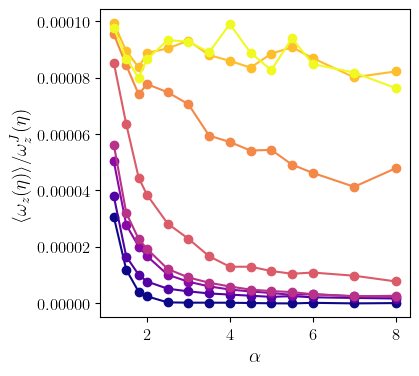

In [ ]:


fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ratio_omega = np.zeros((len(cofs), 1, len(aspect_ratios)))


for i_cof, cof_val in enumerate(cofs):
    theta_shifted = np.where(theta_d[i_cof, i_I, :] < 0, theta_d[i_cof, i_I, :] + np.pi, theta_d[i_cof, i_I, :])

    for j, alpha in enumerate(aspect_ratios):
        beta = (alpha**2flow - 1) / (alpha**2 + 1)

        thetas = theta_bins[i_cof, 0, j, :]
        omega_theta = omega_bins[i_cof, 0, j, :]
        std_omega_theta = std_omega_bins[i_cof, 0, j, :]

        value_at_eta = np.interp(theta_shifted[j], thetas, omega_theta)

        jeffrey_value_at_eta = -(1 - beta * np.cos(2 * theta_shifted[j])) / 2

        ratio_omega[i_cof, 0, j] = value_at_eta / jeffrey_value_at_eta

    ax.plot(
        aspect_ratios,
        ratio_omega[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        marker='o'
    )

ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel("$\\langle \\omega_z(\\eta) \\rangle / \\omega_z^{{J}}(\\eta)$")
# ax.set_ylabel("$2\omega_z \\sqrt{1-\\beta^2} /\dot\gamma$")
# ax.grid(True)
plt.savefig(f"omega_vs_jeffrey_at_eta_{I}.png", dpi=300, bbox_inches='tight')

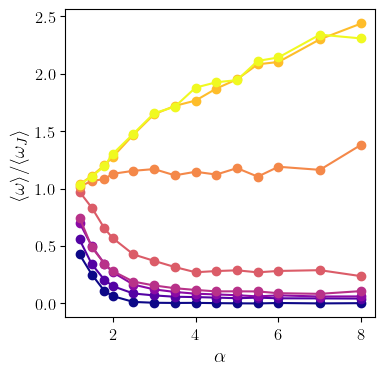

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ratio_omega = np.zeros((len(cofs), 1, len(aspect_ratios)))


for i_cof, cof_val in enumerate(cofs):
   
    for j, alpha in enumerate(aspect_ratios):
        beta = (alpha**2 - 1) / (alpha**2 + 1)
        jeffrey_value = shear_rates[i_cof, 0, j] / 2 * np.sqrt(1 - beta**2)
        ratio_omega[i_cof, 0, j] =  - omega[i_cof, 0, j, 2]  / jeffrey_value

    ax.plot(
        aspect_ratios,
        ratio_omega[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        marker='o'
    )
flow
ax.set_xlabel(f"$\\alpha$")
ax.set_ylabel("$\\langle \\omega \\rangle / \\langle \\omega_{{J}} \\rangle$")
# ax.set_ylabel("$2\omega_z \\sqrt{1-\\beta^2} /\dot\gamma$")
# ax.grid(True)
plt.savefig(f"omega_vs_jeffrey_total.png", dpi=300, bbox_inches='tight')

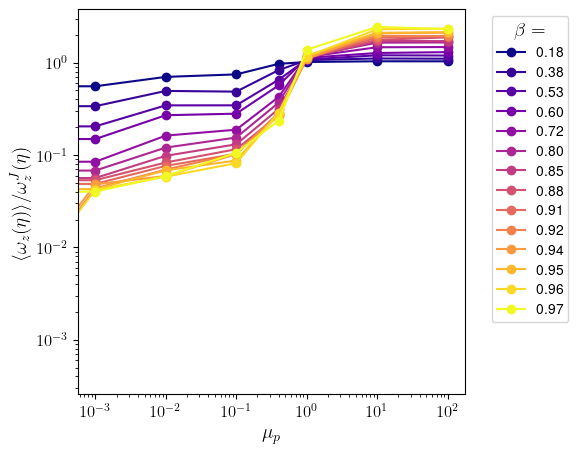

In [64]:
# plot rmse as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

cmap_beta = plt.cm.viridis
colors_beta = [cmap(i / (len(aspect_ratios) - 1)) for i in range(len(aspect_ratios))]

for i_alpha, alpha_val in enumerate(aspect_ratios):
    beta = (alpha_val**2 - 1) / (alpha_val**2 + 1)
    cofs = np.array(cofs)
    ax.loglog(
        cofs,
        ratio_omega[:, 0, i_alpha] ,
        label=f"{beta:.2f}",
        color=colors_beta[i_alpha],
        marker='o'
    )
    
ax.set_xlabel(f"$\\mu_p$")
ax.set_ylabel("$\\langle \\omega_z(\\eta) \\rangle / \\omega_z^{{J}}(\\eta)$")
# ax.set_ylim(0.01, 10)
ax.legend(title="$\\beta=$", bbox_to_anchor=(1.05, 1.0), fontsize=10)


/tmp/ipykernel_10320/402365269.py:20: RuntimeWarning: divide by zero encountered in divide
  Pis[i_cof, 0, :] = Pe / (U1_theoretical[i_cof, 0, :] * S2_scalar_theoretical[i_cof, 0, :])


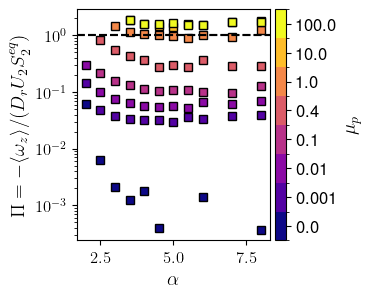

In [73]:
cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]

# plot the Peclet number with the measured D_rn
fig, ax = plt.subplots(1, 1, figsize=(3, 3), sharey=True)

# if ax is not iterable, make it iterable
if not isinstance(ax, np.ndarray):
    ax = [ax]

beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
Pis = np.zeros((len(cofs), 1, len(aspect_ratios)))
mask_S2 = S2_scalar_theoretical > 0.05
for i_cof, cof_val in enumerate(cofs):
    Pe = (-omega[i_cof, 0, :, 2] ) / (D_r[i_cof, 0, :]) 
    # Pe = central_omega_norm[i_cof, :]
    U1_curr = U1_theoretical[i_cof, 0, :]
    S2_curr = S2_scalar_theoretical[i_cof, 0, :]
    S2_mask = S2_curr * U1_curr < 1.0
    Pis[i_cof, 0, :] = Pe / (U1_theoretical[i_cof, 0, :] * S2_scalar_theoretical[i_cof, 0, :])
    Pis[i_cof, 0, S2_mask] = np.nan
    Pe[~S2_mask] = np.nan

    ax[0].plot(
        aspect_ratios,
        Pis[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        markeredgecolor='k',
    )

# ax.set_xlabel(f"$\\alpha$")
ax[0].set_xlabel("$\\alpha$")
# ax.set_ylabel("$\\chi Pe/ 6 U S_2$")
ax[0].set_ylabel("$\\Pi = - \\langle \\omega_z \\rangle / (D_r U_2 S_2^{eq})$")
# ax.set_ylabel("$\\Pi =  \\chi (1 -S_2)/ ( C U S_2)$")
ax[0].set_yscale('log')

ax[0].axhline(1.0, color='k', linestyle='--', linewidth=1.5, label="$\\Pi = 1$")

cmap_discrete = mcolors.ListedColormap(colors_cof)

bounds = np.arange(len(cofs) + 1)
norm = mcolors.BoundaryNorm(bounds, cmap_discrete.N)

sm = cm.ScalarMappable(cmap=cmap_discrete, norm=norm)

cbar = fig.colorbar(sm, ax=ax[0], pad=0.02)

cbar.set_ticks(np.arange(len(cofs)) + 0.5)
cbar.set_ticklabels([str(val) for val in cofs])
cbar.set_label("$\\mu_p$") # Or whichever label you prefer for friction
# ax.set_xlim(2.5, 8.1)
ax[0].axhline(1.0, color='k', linestyle='--', linewidth=1.5, label="$\\Pi = 1$")
fig.savefig(f"Pi_vs_alpha_I_{I}.pdf", dpi=300, bbox_inches='tight')

In [66]:
mask_S2 = S2_scalar_theoretical > 0.05


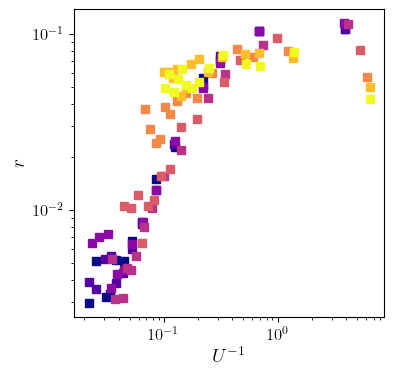

In [67]:
cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]

# plot the Peclet number with the measured D_rn
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)
for i_cof, cof_val in enumerate(cofs):
    Pe = -omega[i_cof, 0, :, 2] / shear_rates[i_cof, 0, :]
    ax.loglog(
        1/U1_theoretical[i_cof, 0, :],
        biaxiality[i_cof, 0, :],
        's',
        label=f"{cof_val}",
        color=colors_cof[i_cof]
    )
ax.set_ylabel("$r$")
ax.set_xlabel("$U^{-1}$")
ax.set_yscale('log')
# ax.set_xlim(0.01, 0.25)
# ax.axhline(1.0, color='k', linestyle='--', linewidth=1.5, label="$\\Pi = 1$")
# fig.savefig(f"omega_over_shear_rate_vs_alpha.pdf", dpi=300, bbox_inches='tight')

/tmp/ipykernel_10320/3466313150.py:70: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(-.1, 3)


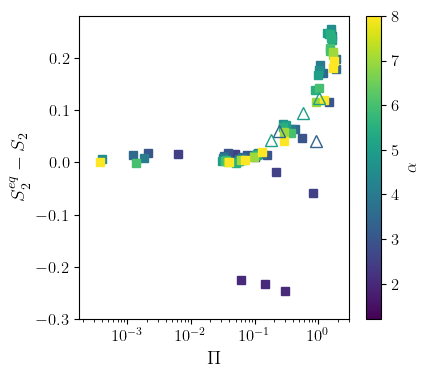

In [68]:
Pis_rods = np.array([[[9.72728802e+01, 2.44844449e-01, 1.82242573e-01]],
 [[7.43852787e+02, 9.09277639e-01, 5.67257410e-01]],
 [[8.98287482e+02, 7.54410380e+01, 1.03988551e+00]]]
)

biaxiality_rods = np.array([[[0.04368842, 0.01670691, 0.00980193]],
       [[0.0767007 , 0.03985574, 0.02474923]],
       [[0.07669505, 0.05775459, 0.04556887]]])


delta_s_rods = np.array([[[ 0.70095522, -0.06069196, -0.04359215]],
 [[ 0.50895832, -0.04028581, -0.09397234]],
 [[ 0.38506512,  0.60996797, -0.12335939]]])



rod_alphas = np.array([2.0, 3.3, 5.0])

spheroid_alphas_to_plot = aspect_ratios[aspect_ratios > 1.0]  # Filter for spheroids with alpha > 2.0

# Combine all alphas to find the true min/max for the colormap
all_alphas = np.union1d(spheroid_alphas_to_plot, rod_alphas)
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=all_alphas.min(), vmax=all_alphas.max())

fig, ax = plt.subplots(1, 1, figsize=(4.5, 4))


# --- 2. Plot Spheroids (Your original loop, modified) ---
for alpha in spheroid_alphas_to_plot:
    i_alpha_spheroid = np.where(aspect_ratios == alpha)[0][0]
    beta_i = (alpha**2 - 1) / (alpha**2 + 1)
    # b_jeffrey = biax_jeffrey(alpha)
    biaxiality_talbot = intepolator(biax_no_noise[:, 0], biax_no_noise[:, 1])(beta_i)
    Pe = -omega[i_cof, 0, i_alpha_spheroid, 2] / D_r[i_cof, 0, i_alpha_spheroid]
    ax.semilogx(
        Pis[:, 0, i_alpha_spheroid],  # Use the pre-calculated Pi
        # np.abs(S2_scalar[:, 0, i_alpha_spheroid] - S2_scalar_theoretical[:, 0, i_alpha_spheroid]) / S2_scalar[:, 0, i_alpha_spheroid],  # Normalized biaxiality
        -(S2_scalar[:, 0, i_alpha_spheroid] - S2_scalar_theoretical[:, 0, i_alpha_spheroid]),  
        's',  # Square marker for spheroids
        # label=f"Spheroid $\\alpha={alpha:.1f}$",
        color=cmap(norm(alpha)),  # Get color from normalized map
        alpha=1.0 #if alpha >= 3.0 else 0.4  # Different alpha for visibility
    )

# #-- 3. Plot Rods (New loop) ---
for i_alpha_rod, alpha in enumerate(rod_alphas):
    ax.plot(
        Pis_rods[:, 0, i_alpha_rod],
        -delta_s_rods[:, 0, i_alpha_rod],
        '^',  # Triangle marker for rods
        markersize=8,
        label=f"${alpha:.1f}$",
        color=cmap(norm(alpha)),  # Get color from the SAME map
        alpha=1.0,
        mfc='none' # Use a hollow marker to distinguish further
    )

# add colorbar for the aspect ratio
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\alpha$", fontsize=12)

# ax.legend(title= r"Rod $\alpha=$", bbox_to_anchor=(.45, .5), fontsize=12)
ax.set_xlabel("$\\Pi$")
# ax.set_ylabel("$\\lambda_2- \\lambda_3$")
ax.set_ylabel("$S_2^{{eq}} - S_2$")  # Relative error in S2

plt.ylim(-0.3, 0.28)
ax.set_xlim(-.1, 3)
plt.tight_layout()
plt.savefig(f"delta_s2_vs_Pi_all.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [69]:
S2_scalar_theoretical[:, 0, 4]- S2_scalar[:, 0, 4]

array([ 0.01659896,  0.01639933,  0.00999428, -0.01801039, -0.05893836,
       -0.51624706, -0.38302589, -0.3726586 ])

In [70]:
biaxiality_rods = np.array([[[0.04368842, 0.01670691, 0.00980193]],
       [[0.0767007 , 0.03985574, 0.02474923]],
       [[0.07669505, 0.05775459, 0.04556887]]])

rod_alphas = np.array([2.0, 3.3, 5.0])

spheroid_alphas_to_plot = aspect_ratios[aspect_ratios >= 2.0]


# Combine all alphas to find the true min/max for the colormap
all_alphas = np.union1d(spheroid_alphas_to_plot, rod_alphas)
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=all_alphas.min(), vmax=all_alphas.max())

fig, ax = plt.subplots(1, 1, figsize=(4.6, 4))

# --- 2. Plot Spheroids (Your original loop, modified) ---
for alpha in spheroid_alphas_to_plot:
    i_alpha_spheroid = np.where(aspect_ratios == alpha)[0][0]
    beta_i = (alpha**2 - 1) / (alpha**2 + 1)
    # b_jeffrey = biax_jeffrey(alpha)
    biaxiality_talbot = intepolator(biax_no_noise[:, 0], biax_no_noise[:, 1])(beta_i)
    Pe = -omega[i_cof, 0, i_alpha_spheroid, 2] / D_r[i_cof, 0, i_alpha_spheroid]
    Pe = Pe**1
    ax.loglog(
        Pis[:, 0, i_alpha_spheroid],  # Use the pre-calculated Pi
        biaxiality[:, 0, i_alpha_spheroid], 
        's',  # Square marker for spheroids
        # label=f"Spheroid $\\alpha={alpha:.1f}$",
        color=cmap(norm(alpha)),  # Get color from normalized map
        alpha=1.0 #if alpha >= 3.0 else 0.4  # Different alpha for visibility
    )

# #-- 3. Plot Rods (New loop) ---
for i_alpha_rod, alpha in enumerate(rod_alphas):
    ax.loglog(
        Pis_rods[:, 0, i_alpha_rod],
        biaxiality_rods[:, 0, i_alpha_rod],
        '^',  # Triangle marker for rods
        markersize=8,
        label=f"${alpha:.1f}$",
        color=cmap(norm(alpha)),  # Get color from the SAME map
        alpha=1.0,
        mfc='none' # Use a hollow marker to distinguish further
    )

ax.legend(title= r"Rod $\alpha=$", bbox_to_anchor=(.35, 1.0), fontsize=12)
ax.set_xlabel("$\\Pi$")
ax.set_ylabel("$r$")
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(effer"$\alpha$", fontsize=12)
# ax.set_ylabel("$|S_2 - S_2^{{eq}}| / S_2$")  # Relative error in S2
plt.ylim(0.002, 0.1)
ax.set_xlim(0.0001, 3)
plt.savefig(f"biaxiality_vs_Pi.pdf", dpi=300, bbox_inches='tight')
plt.show()

SyntaxError: invalid syntax (464658591.py, line 51)

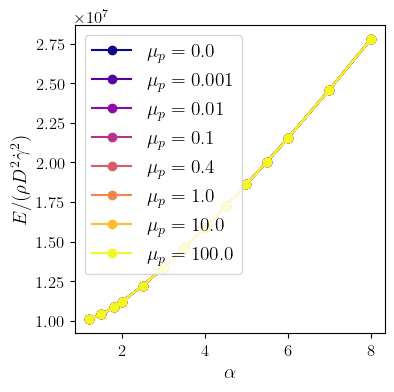

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
Young_mod = 5.0e6
density=1000
eq_diam = np.array([2* (alpha**(1/3)) for alpha in aspect_ratios])  # Assuming volume conservation for spheroids
for i_cof, cof_val in enumerate(cofs):
    # plot shear rate vs. aspect ratio for each friction coefficient
    eq_young_mod = Young_mod / (density * (eq_diam * shear_rates[i_cof, 0, :])**2)

    ax.plot(
        aspect_ratios,
        eq_young_mod,
        'o-',
        label=f"$\\mu_p = {cof_val}$",
        color=colors_cof[i_cof]
    )
ax.set_xlabel("$\\alpha$")
ax.set_ylabel("$E / (\\rho D^2 \\dot \\gamma^2)$")
ax.legend()

<>:24: SyntaxWarning: invalid escape sequence '\P'
<>:24: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_8429/2731286479.py:24: SyntaxWarning: invalid escape sequence '\P'
  ax.set_xlabel("$\Pi$")


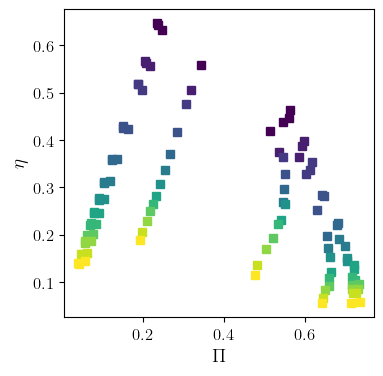

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
beta = (aspect_ratios**2 - 1) / (aspect_ratios**2 + 1)

large_aspect_ratios = aspect_ratios[aspect_ratios >= 1.5]
cmap_alpha = plt.cm.viridis
colors_alpha = [cmap_alpha(i / (len(large_aspect_ratios) - 1)) for i in range(len(large_aspect_ratios))]

negative_flag = np.where(theta_d < 0, True, False)
theta_d_corrected = np.where(negative_flag, theta_d + np.pi, theta_d)

for i_alpha, alpha in enumerate(large_aspect_ratios):
    i_alpha2 = np.where(aspect_ratios == alpha)[0][0]
    

    ax.plot(
        p_xy[:, 0, i_alpha2] / p_yy[:, 0, i_alpha2],
        theta_d_corrected[:, 0, i_alpha2],  # factor 3 accounts for the use of cos(2*theta) instead of P_2(cos(theta))
        's',
        label=f"{alpha}",
        color=colors_alpha[i_alpha]
    )

# ax.legend(title="$\\alpha$", bbox_to_anchor=(1.05, 1.0), fontsize=12)
ax.set_xlabel("$\Pi$")
# ax.set_ylabel("$\\lambda_2- \\lambda_3$")
ax.set_ylabel("$\\eta$")
# ax.set_xlim(0.001, 10)
plt.savefig(f"eta_vs_Pi.pdf", dpi=300, bbox_inches='tight')

<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_8429/2874984403.py:24: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel("$\langle \\omega_z   \\rangle  /\\dot \\gamma $")


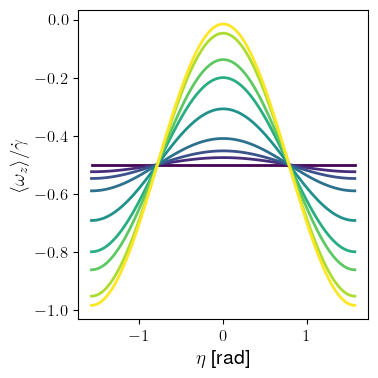

In [ ]:
alpha_values = np.array([1.00, 1.05, 1.1, 1.2, 1.5, 2.0, 2.5, 4.5, 8.0])
cmap = plt.cm.viridis
colors_alpha = [cmap(i / (len(alpha_values) - 1)) for i in range(len(alpha_values))]

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

thetas = np.linspace(-np.pi/2, np.pi/2, 200)
for i, alpha_index in enumerate(alpha_values):
    
    beta = (alpha_values[i]**2 - 1) / (alpha_values[i]**2 + 1)
    theta_fit = np.linspace(-np.pi/2, np.pi/2, 100)
    jeffrey_omega = -(1 - beta * np.cos(2 * theta_fit)) / 2
        
    ax.plot(
        theta_fit,
        jeffrey_omega,
        color=colors_alpha[i],
        label='Jeffrey',
        linewidth=2
    )

    ax.set_xlabel("$\\eta$ [rad]")
    
ax.set_ylabel("$\langle \\omega_z   \\rangle  /\\dot \\gamma $")
fig.tight_layout()
fig.savefig(f"avg_omega_bin_pure_jeffrey.svg", dpi=300, bbox_inches='tight')


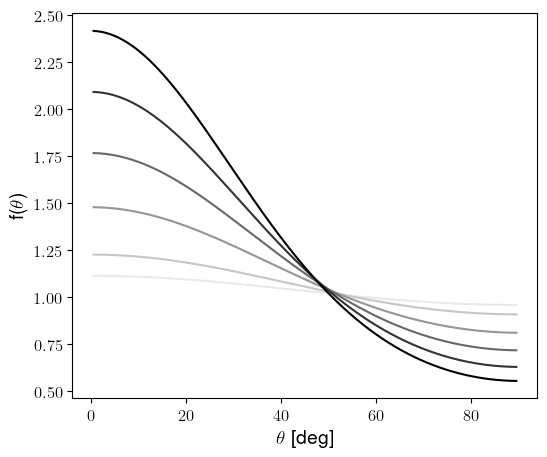

In [ ]:
# plot a generic maier saupe distribution for different S2 values

plt.figure(figsize=(6, 5))
thetas = np.linspace(0.01, np.pi/2-0.01, 200)

S2_values = [0.01, 0.1, 0.2, 0.4, 0.6, 0.8, 0.98]

cmap = plt.cm.Grays

colors_S2 = [cmap(i / (len(S2_values) - 1)) for i in range(len(S2_values))]
for i, S2 in enumerate(S2_values):
    exponent = (3 * np.cos(thetas)**2 - 1) * S2 / 2
    distribution = np.exp(exponent)
    distribution /= np.trapezoid(distribution*np.sin(thetas), thetas)  # Normalize the distribution

    plt.plot(thetas*180/np.pi, distribution, label=f"$S_2 = {S2}$", color=colors_S2[i])

plt.xlabel("$\\theta$ [deg]")
plt.ylabel("f($\\theta$)")
plt.savefig(f"maier_saupe_distribution.svg", dpi=300, bbox_inches='tight')

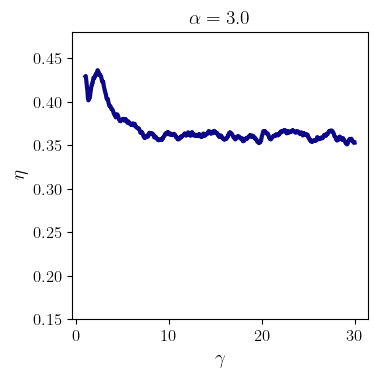

In [ ]:
# plot s2 over time for a fixd alpha and different cofs
alpha_indexs = [5]
alpha_values = aspect_ratios[alpha_indexs]

cmap = plt.cm.plasma
colors_cof = [cmap(i / (len(cofs) - 1)) for i in range(len(cofs))]


fig, ax = plt.subplots(1, len(alpha_values), figsize=(4*len(alpha_values), 4), sharey='row')
for i, alpha_index in enumerate(alpha_indexs):
    for i_cof, cof_val in enumerate(cofs):
        # remove trailing zeros to arrays
        gamma = strains[i_cof, 0, alpha_index, :]
        S2_t = S2_over_time[i_cof, 0, alpha_index, :]
        biaxiality_t = biaxiality_over_time[i_cof, 0, alpha_index, :]
        eta = angle_over_time[i_cof, 0, alpha_index, :]

        gamma = np.where(gamma != 0, gamma, np.nan)  # Replace zeros with NaN for better plotting
        S2_t = np.where(S2_t != 0, S2_t, np.nan)  # Replace zeros with NaN for better plotting
        eta = np.where(eta != 0, eta, np.nan)
        biaxiality_t = np.where(biaxiality_t != 0, biaxiality_t, np.nan)

        if cof_val <= 0.0:

            ax.plot(
                gamma[100:],
                eta[100:],
                label=f"{cof_val}",
                color=colors_cof[i_cof],
                linewidth = 3, 
                # marker='o'
            )


    ax.set_title(f"$\\alpha = {alpha_values[i]}$")
    ax.set_xlabel("$\\gamma$")

# ax[0, 0].set_ylabel("$S_2$")
ax.set_ylabel("$\\eta$")
# ax.set_ylabel("$\\lambda_2 - \\lambda_3$")
ax.set_ylim([0.15, 0.48])
fig.tight_layout()
fig.savefig(f"S2_over_time_vs_gamma_alpha_mup0.svg", dpi=600, bbox_inches='tight')

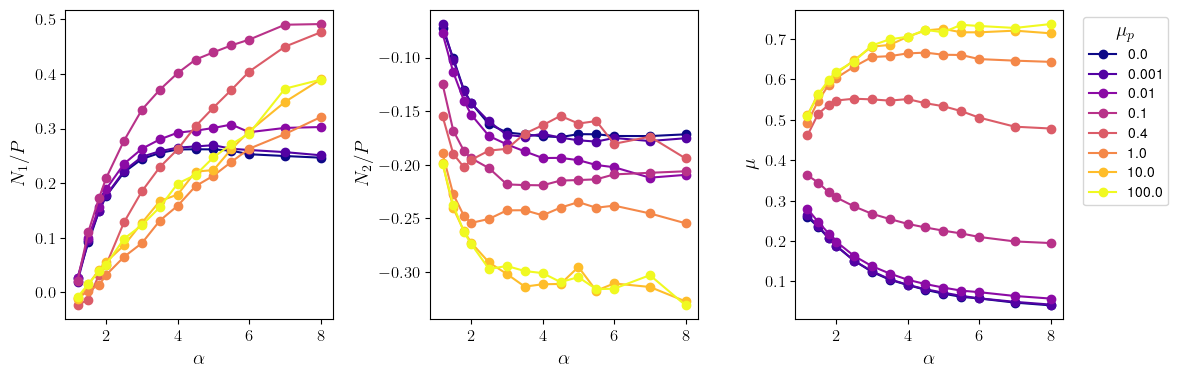

In [ ]:
#plot n1_diff and n2_diff as a function of aspect ratio for different cof
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for i_cof, cof_val in enumerate(cofs):
    ax[0].plot(
        aspect_ratios,
        n1_diff[i_cof, 0, :]/p_yy[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        marker='o'
    )
    ax[1].plot(
        aspect_ratios,
        n2_diff[i_cof, 0, :]/p_yy[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        marker='o'
    )
    ax[2].plot(
        aspect_ratios,
        p_xy[i_cof, 0, :]/p_yy[i_cof, 0, :],
        label=f"{cof_val}",
        color=colors_cof[i_cof],
        marker='o'
    )


ax[0].set_xlabel(f"$\\alpha$")
ax[0].set_ylabel("$N_1/P$")
ax[1].set_xlabel(f"$\\alpha$")
ax[1].set_ylabel("$N_2/P$")
ax[2].set_xlabel(f"$\\alpha$")
ax[2].set_ylabel("$\\mu$")
ax[2].legend(title="$\\mu_p$", bbox_to_anchor=(1.05, 1.0), fontsize=10)
fig.tight_layout()


Text(0.5, 0, '$\\alpha$')

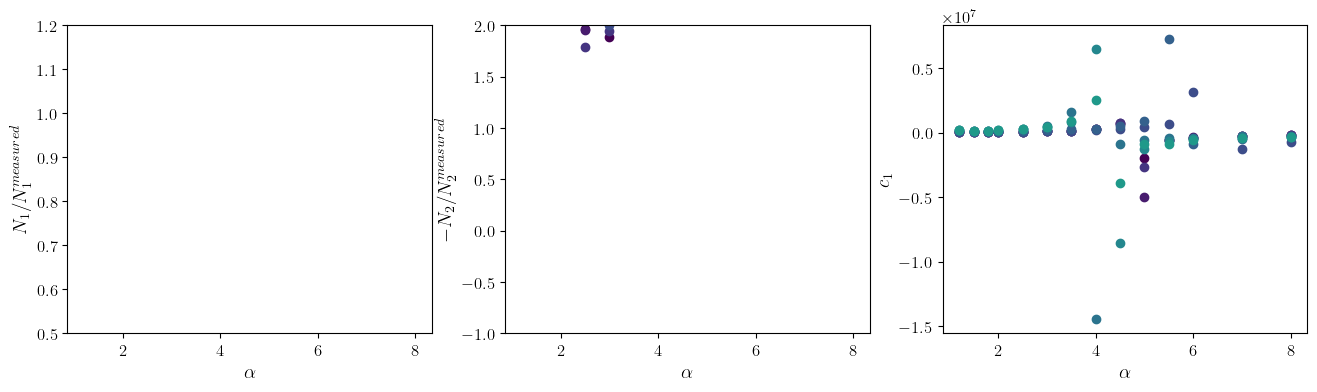

In [ ]:
# for each alpha as a function of cof fit the stress with the pressure and then check the predicted N_1 and N_2 against the computed once

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for i_cof, cof in enumerate(cofs):
    const_fits = np.zeros((len(aspect_ratios)))
    n1s_predicted = np.zeros((len(aspect_ratios)))
    n2s_predicted = np.zeros((len(aspect_ratios)))
    n1s_measured = np.zeros((len(aspect_ratios)))
    n2s_measured = np.zeros((len(aspect_ratios)))
    shear_stress_measured = np.zeros((len(aspect_ratios)))
    shear_stress_predicted = np.zeros((len(aspect_ratios)))

    for i_alpha, alpha in enumerate(aspect_ratios):
        n1_measured = n1_diff[i_cof, 0, i_alpha] / p_yy[i_cof, 0, i_alpha]
        n2_measured = n2_diff[i_cof, 0, i_alpha] / p_yy[i_cof, 0, i_alpha]
        phi_dense = phis[i_cof, 0, i_alpha]
        S2 = S2_tensor[i_cof, 0, i_alpha, :, :]
        S4 = S4_tensor[i_cof, 0, i_alpha, :, :, :, :]

        shear_rate = shear_rates[i_cof, 0, i_alpha]
        strain_tensor = 0.5*np.array([[0, 1, 0], [1, 0, 0], [0, 0, 0]]) * shear_rate 
        
        T1 = np.einsum('ijkl, kl->ij', S4, strain_tensor)  # 2nd order tensor
        T2 = np.einsum('ijkl, kl->ij', S4, S2)  
        T3 = S2@S2 
        T_elastic = -(T3 + phi_dense*S2/3 - T2)
        # const_fit = - p_yy[i_cof, 0, i_alpha] / total_stress[0, 0]
        # const_fits[i_alpha] = const_fit
        # stress_model = const_fit * total_stress

        b = np.array([
            p_yy[i_cof, 0, i_alpha],   # measured sigma_yy
            p_xy[i_cof, 0, i_alpha]    # measured sigma_xy
        ])

        A = np.array([
            [T1[1, 1], T_elastic[1, 1]],  # sigma_yy = row 1, col 1
            [T1[0, 1], T_elastic[0, 1]]   # sigma_xy = row 0, col 1 (symm)
        ])

        c1, c2 = np.linalg.solve(A, b)

        stress_model = c1 * T1 + c2 * T_elastic
        const_fits[i_alpha] = c1

        n1_predicted = (stress_model[0,0] - stress_model[1,1]) / p_yy[i_cof, 0, i_alpha]
        n2_predicted = (stress_model[1,1] - stress_model[2,2]) / p_yy[i_cof, 0, i_alpha] 

        n1s_predicted[i_alpha] = n1_predicted
        n2s_predicted[i_alpha] = n2_predicted
        n1s_measured[i_alpha] = n1_measured
        n2s_measured[i_alpha] = n2_measured
        shear_stress_measured[i_alpha] = p_xy[i_cof, 0, i_alpha]
        shear_stress_predicted[i_alpha] = stress_model[0, 1]

    # ax[0].plot(
    #     aspect_ratios,
    #     n1s_predicted,
    #     '-o',
    #     color=colors[i_cof],)
    # ax[1].plot(
    #     aspect_ratios,
    #     n2s_predicted,
    #     '-o',
    #     color=colors[i_cof],)
    # ax[2].plot(
    #     aspect_ratios,
    #     const_fits,
    #     '-o',
    #     color=colors[i_cof],)
    # ax[3].plot(
    #     aspect_ratios,
    #     shear_stress_predicted,
    #     '-o',
    #     color=colors[i_cof],)

    ax[0].plot(
        aspect_ratios,
        n1s_predicted/n1s_measured,
        'o',
        color=colors[i_cof],)
    ax[1].plot(
        aspect_ratios,
        -n2s_predicted/ n2s_measured,
        'o',
        color=colors[i_cof],)
    ax[2].plot(
        aspect_ratios,
        const_fits,
        'o',
        color=colors[i_cof],)

ax[0].set_ylim(0.5, 1.2)
ax[1].set_ylim(-1, 2)
ax[0].set_ylabel("$N_1/N_1^{measured}$")
ax[1].set_ylabel("$-N_2/N_2^{measured}$")
ax[2].set_ylabel("$c_1$")
ax[0].set_xlabel("$\\alpha$")
ax[1].set_xlabel("$\\alpha$")
ax[2].set_xlabel("$\\alpha$")



In [ ]:
n_densities = 50 
n_aps = 50

densities = np.linspace(0.01, 0.95, n_densities) 
aps = np.linspace(1.1, 8.0, n_aps)

S2_map = np.zeros((n_aps, n_densities))

for i, ap in enumerate(aps):
    # Set a small initial seed for the lowest density of each aspect ratio
    current_guess = (0.2, 0.2) 
    
    for j, density in enumerate(densities):
        correction_density = compute_vega_correction_density(ap, density)

        U_test_2 = correction_density * parsons_volume_approx_p2(ap)
        U_test_4 = correction_density * parsons_volume_approx_p4(ap)

        # Solve for theoretical S2 and S4
        S2, S4 = solve_self_consistent_S2_S4_p4(
            (U_test_2, U_test_4),
            initial_guesses=current_guess
        )
        
        S2_map[i, j] = S2
        
        current_guess = (max(0.05, S2), S4)

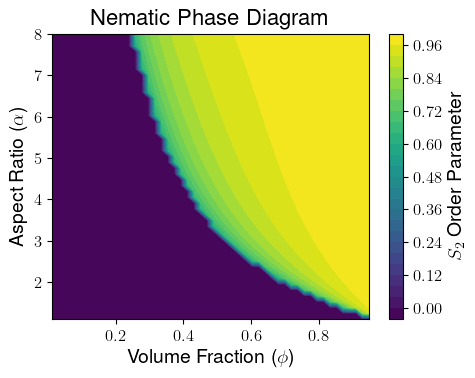

In [ ]:

# 4. Plotting the 2D Heatmap
plt.figure(figsize=(5, 4))

# Create a meshgrid for the X and Y axes
X, Y = np.meshgrid(densities, aps)

# Use contourf for a smooth, interpolated map, or pcolormesh for exact grid pixels
cp = plt.contourf(X, Y, S2_map, levels=30, cmap='viridis')
cbar = plt.colorbar(cp)
cbar.set_label("$S_2$ Order Parameter", fontsize=14)

plt.xlabel("Volume Fraction ($\\phi$)", fontsize=14)
plt.ylabel("Aspect Ratio ($\\alpha$)", fontsize=14)
plt.title("Nematic Phase Diagram", fontsize=16)

# Optional: Add a line denoting the Isotropic-Nematic transition boundary
# plt.contour(X, Y, S2_map, levels=[0.1], colors='red', linestyles='dashed')

plt.tight_layout()
plt.show()